# 03 — Modeling: predict `is_long_stay` (Dogs & Cats, separately)

**Logistic Regression** (regularized, interpretable baseline) vs **XGBoost** (main model), on one shared pipeline.

**Rules fixed before this notebook:**
1. Dogs and cats are modeled **separately** — their feature signals differ (§10); never pooled.
2. **Never features (leakage):** `outcome_type, outcome_subtype, outcome_date, length_of_stay_days, is_adopted, outcome_category`. `length_of_stay_days` is the *parent* of the target (`is_long_stay = length_of_stay_days > 30`), so it is doubly disqualified.
3. **Color dropped for both species** (`primary_color, secondary_color, pattern`): MI ≤ 0.0013, far below dog `primary_breed` (0.029), and a decision-fold ablation agreed.

**Selected features — Dog (10):** `intake_reason, primary_breed, breed_size, intake_health_condition, sex, age_days, is_sn, is_mix, intake_month, intake_year`. **Cat (9):** the same minus `breed_size` — ~95% of cats are domestic short/medium/longhair, so there is little size structure to find (measured ±0.005, sign flips).

Three were **not** in the MI-screened set:
- **`breed_size`** (dog only, `small` < 25 lbs) — Appendix 1 ties the 2023 break to the fixed 30-day line, and size sets how close an animal already sits to it. Backtested −0.002 / +0.007 / +0.009 AUC (2022 / 2023 / 2024): a recent-fold gain, not a uniform one. The data has no weight column, so the mapping is external domain knowledge, labelled as such in `01_cleaning`.
- **`intake_month`** — MI ranks it near zero (0.0002 dog / 0.0084 cat), but **MI is marginal and blind to conditional effects**, so inclusion rests on the backtest instead: +0.009 / +0.004 / +0.001 AUC for cats; dogs are flat (−0.007 / +0.002 / −0.005).
- **`intake_year`** — known at intake, so not leakage. An unseen test year saturates at the tree's last split and inherits the most-recent-era rules: implicit recency weighting. Backtested at −0.003 / +0.013 / +0.009 AUC (2022 / 2023 / 2024) against a calibration cost (§9.2) — a measured trade, not a free win.

**Evaluation = rolling-origin backtest:** for each test year *Y* in 2020–2024, train on all prior years (`intake_year < Y`) and test on *Y*. The long-stay rate drifts across these years, so a random split would leak the future — and that drift is why class weights are computed **per fold** (§8). `intake_year` is both fold key and feature: no conflict, since a fold's test year is a constant.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, recall_score,
                             confusion_matrix, brier_score_loss, precision_recall_curve)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
import shap

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('libraries loaded | xgboost + shap OK')

libraries loaded | xgboost + shap OK


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load, filter, build the modeling frame

The frame includes the **467 still-in-shelter rows** appended in `01_cleaning` (Step 8b): confirmed long-stays (`is_long_stay = 1`) for animals with no outcome yet, concentrated in **2024–2025**. They carry `date_of_birth = NaT` (age comes from the intake age string) and `outcome_* = 'still in shelter'` — the outcome columns are on the leakage list, so these rows contribute only the target and intake-time features.

In [2]:
# ====== EDIT THIS IF YOUR DATA LIVES ELSEWHERE ======
DATA_PATH = '../data/processed/df_full_merged.csv'
# ====================================================
df = pd.read_csv(DATA_PATH)
print('df raw:', df.shape)

TARGET = 'is_long_stay'
if TARGET not in df.columns:                      # guard: CSV may predate is_long_stay
    df[TARGET] = (df['length_of_stay_days'] > 30).astype(int)
    print(f'WARNING: {TARGET} missing — recomputed (length_of_stay_days > 30).')
# Rule 2: leakage columns — listed so they are never selected as features.
# Target switched to is_long_stay, so the former target is_adopted and the outcome-derived
# outcome_category are leakage sources too (both known only after the outcome).
LEAKAGE_COLS = ['outcome_type', 'outcome_subtype', 'outcome_date',
                'length_of_stay_days', 'is_adopted', 'outcome_category']
print('leakage (never used as features):', LEAKAGE_COLS)
print('target:', TARGET)

df raw: (162932, 27)
leakage (never used as features): ['outcome_type', 'outcome_subtype', 'outcome_date', 'length_of_stay_days', 'is_adopted', 'outcome_category']
target: is_long_stay


## 3. Deterministic feature derivation

These transforms use **no learned parameters** — fixed `age_bucket` bins (missing age → its own `Unknown` bucket), the `is_sn_cat` mapping (missing → `sn_unknown`, for the LR's one-hot path), a fixed `intake_health_condition` merge (keep the well-populated levels, rest → `Other`), and `sex` / `intake_reason` NaN → `'Unknown'` so the encoders never choke. Applying them to the whole frame before the split therefore introduces no leakage; anything data-driven (top-N breeds) is deferred to the train-only preprocessor in §6.

The appended still-in-shelter rows carry `date_of_birth = NaT`, so age handling is exercised on them directly: `age_at_intake_days` is filled from the intake age string (one row is unparseable → the `Unknown` bucket for LR), while XGBoost consumes the raw numeric column. No row is dropped for missing DOB. **Color is not derived** — it is not in the selected feature sets; `intake_month` and `breed_size` arrive ready-made from `01_cleaning`.

In [3]:
# --- age_bucket for LR (NaN age -> its own 'Unknown' bucket) ---
AGE_BINS   = [0, 60, 180, 365, 730, 1825, 3650, 5475, np.inf]
AGE_LABELS = ['<2mo', '2-6mo', '6-12mo', '1-2yr', '2-5yr', '5-10yr', '10-15yr', '15yr+']
df['age_bucket'] = pd.cut(df['age_at_intake_days'], bins=AGE_BINS, labels=AGE_LABELS,
                          right=False).astype('object').fillna('Unknown')

# --- is_sn (legal feature: recorded at intake). Unknown sex -> NaN -> explicit category for LR ---
df['is_sn_cat'] = df['is_previously_spayed_neutered'].map({1.0: 'sn_yes', 0.0: 'sn_no'}).fillna('sn_unknown')

# --- intake_health_condition: keep the well-populated levels, merge the rest into 'Other' ---
# (this folds the spec's small categories Medical/Aged/Other, plus other tiny ones, into 'Other')
HEALTH_KEEP = ['Normal', 'Injured', 'Sick', 'Nursing', 'Neonatal']
_before = df['intake_health_condition'].value_counts().to_dict()
df['intake_health_condition'] = df['intake_health_condition'].where(
    df['intake_health_condition'].isin(HEALTH_KEEP), 'Other')
# fill any stray NaN in OHE categorical inputs so encoders never choke
for c in ['sex', 'intake_reason']:
    df[c] = df[c].fillna('Unknown')

print('health_condition merged ->', df['intake_health_condition'].value_counts().to_dict())
print('  (merged out of:', {k: v for k, v in _before.items() if k not in HEALTH_KEEP}, ')')
# intake_month and breed_size arrive ready-made from 01_cleaning; nothing to derive here.
df['intake_month'] = df['intake_month'].astype(int)
df['intake_year']  = df['intake_year'].astype(int)
if 'breed_size' in df.columns:
    df['breed_size'] = df['breed_size'].fillna('unknown')

health_condition merged -> {'Normal': 140027, 'Injured': 9283, 'Sick': 6017, 'Nursing': 3721, 'Other': 1981, 'Neonatal': 1903}
  (merged out of: {'Medical': 589, 'Aged': 521, 'Other': 337, 'Pregnant': 149, 'Feral': 143, 'Med Attn': 81, 'Behavior': 79, 'Unknown': 29, 'Med Urgent': 21, 'Neurologic': 11, 'Parvo': 11, 'Space': 4, 'Agonal': 4, 'Panleuk': 1, 'Congenital': 1} )


## 4. Rolling-origin backtest (expanding-window time splits)

For each test year *Y* in 2020–2024, train on **all** prior years (`intake_year < Y`) and test on *Y* alone; the training window expands by one year each step.

| fold | train years | test year | role |
|---|---|---|---|
| 1 | 2013–2019 | 2020 | trace only (no decisions) |
| 2 | 2013–2020 | 2021 | trace only (no decisions) |
| 3 | 2013–2021 | 2022 | **decision** (feature ablations) |
| 4 | 2013–2022 | 2023 | **decision** (feature ablations) |
| 5 | 2013–2023 | 2024 | **test** (held out; also §10 interpretability) |

The decision folds own the **feature** keep/drop calls (§7) and nothing else. The operating point is not one of these decisions: the top 30% of the trailing 90 days is a policy rule (§8.1) applied identically to all five folds, so 2022 and 2023 supply out-of-sample *evidence* about it, never an input to it.

Every fold is strictly past → future, and every data-driven step is re-fit on that fold's training years only. The long-stay rate drifts across these years.



In [4]:
# ---- rolling-origin backtest folds: test year Y, train = all years < Y (expanding window) ----

TEST_YEARS = [2020, 2021, 2022, 2023, 2024]
# ONE constant drives feature keep/drop (§7); rationale in §4. It does NOT drive the operating
# point — §8.1's rule is policy-set and only *evaluated* on these folds.
DECISION_YEARS = [2022, 2023]
REF_TEST_YEAR  = 2024   # held-out TEST fold (headline) + §10 interpretability
assert REF_TEST_YEAR not in DECISION_YEARS, 'the test fold must never drive a decision'

def fold_frames(test_year):
    tr = df[df.intake_year <  test_year]
    te = df[df.intake_year == test_year]
    return tr, te

print('Rolling-origin folds (expanding window):')
for Y in TEST_YEARS:
    tr, te = fold_frames(Y)
    yr0, yr1 = int(tr.intake_year.min()), int(tr.intake_year.max())
    tag = ('  <- DECISION (feature ablations)' if Y in DECISION_YEARS else
           '  <- TEST (held out)' if Y == REF_TEST_YEAR else '  <- trace only (no decisions)')
    print(f'  train {yr0}-{yr1} (n={len(tr):>6,}, long_stay {tr[TARGET].mean():.3f})  ->  '
          f'test {Y} (n={len(te):>5,}, long_stay {te[TARGET].mean():.3f}){tag}')

def species_frames(test_year):
    tr, te = fold_frames(test_year)
    TR = {sp: tr[tr.animal_type == sp].copy() for sp in ['Dog', 'Cat']}
    TE = {sp: te[te.animal_type == sp].copy() for sp in ['Dog', 'Cat']}
    return TR, TE

# DECISION folds -> §7 ablations (and out-of-sample evidence for §8.1's fixed rule).
# REFERENCE fold -> headline + §10 interpretability.
DEC_TR, DEC_TE = {}, {}
for Y in DECISION_YEARS:
    DEC_TR[Y], DEC_TE[Y] = species_frames(Y)
REF_TR, REF_TE = species_frames(REF_TEST_YEAR)
print()
for Y in DECISION_YEARS:
    print(f'decision fold (feature ablations)          = train <= {Y-1} -> evaluate {Y}: '
          + ', '.join(f'{sp} train {len(DEC_TR[Y][sp]):,}/eval {len(DEC_TE[Y][sp]):,}' for sp in ['Dog', 'Cat']))
print(f'test fold     (held out, no decisions)     = train <= {REF_TEST_YEAR-1} -> test {REF_TEST_YEAR}: '
      + ', '.join(f'{sp} train {len(REF_TR[sp]):,}/test {len(REF_TE[sp]):,}' for sp in ['Dog', 'Cat']))

Rolling-origin folds (expanding window):
  train 2013-2019 (n=106,747, long_stay 0.169)  ->  test 2020 (n=8,838, long_stay 0.238)  <- trace only (no decisions)
  train 2013-2020 (n=115,585, long_stay 0.174)  ->  test 2021 (n=11,285, long_stay 0.217)  <- trace only (no decisions)
  train 2013-2021 (n=126,870, long_stay 0.178)  ->  test 2022 (n=11,143, long_stay 0.246)  <- DECISION (feature ablations)
  train 2013-2022 (n=138,013, long_stay 0.183)  ->  test 2023 (n=10,638, long_stay 0.307)  <- DECISION (feature ablations)


  train 2013-2023 (n=148,651, long_stay 0.192)  ->  test 2024 (n=11,207, long_stay 0.297)  <- TEST (held out)



decision fold (feature ablations)          = train <= 2021 -> evaluate 2022: Dog train 75,708/eval 6,470, Cat train 51,162/eval 4,673
decision fold (feature ablations)          = train <= 2022 -> evaluate 2023: Dog train 82,178/eval 5,058, Cat train 55,835/eval 5,580
test fold     (held out, no decisions)     = train <= 2023 -> test 2024: Dog train 87,236/test 5,168, Cat train 61,415/test 6,039


## 5. Per-species feature sets & breed policy

The feature sets were fixed in the MI/Pearson selection pass (see overview). Here: record them in code, set the breed policy, print the final per-species lists.

In [5]:
# ---- selected feature sets (color excluded; intake_month kept on backtest evidence, not MI) ----

FEATURES = {
    'Dog': ['intake_reason', 'primary_breed', 'breed_size', 'intake_health_condition', 'sex',
            'age_days', 'is_sn', 'is_mix', 'intake_month', 'intake_year'],
    'Cat': ['sex', 'intake_reason', 'intake_health_condition', 'primary_breed',
            'age_days', 'is_sn', 'is_mix', 'intake_month', 'intake_year'],
}
USE_BREED_SIZE = {'Dog': True, 'Cat': False}

DOG_BREED_TOPN, CAT_BREED_TOPN = 60, 4
BREED_TOPN = {'Dog': DOG_BREED_TOPN, 'Cat': CAT_BREED_TOPN}
USE_BREED  = {'Dog': True, 'Cat': True}
for sp in ['Dog', 'Cat']:
    print(f'{sp} features ({len(FEATURES[sp])}): {FEATURES[sp]}')
print('USE_BREED =', USE_BREED, '| BREED_TOPN =', BREED_TOPN)


# cat breed context: most cats are Domestic Shorthair, keep top-4 + fold the rest into 'Other'
ct = DEC_TR[DECISION_YEARS[-1]]['Cat']   # context only: last decision fold's train frame
g = ct.groupby('primary_breed')[TARGET].agg(rate='mean', n='count')
g = g[g['n'] >= 100].sort_values('n', ascending=False)

print(g.round(3).to_string())
cov = ct['primary_breed'].isin(['Domestic Shorthair', 'Domestic Medium Hair',
                                'Domestic Longhair', 'Siamese']).mean()
print(f'top-{CAT_BREED_TOPN} cat breeds cover {cov:.1%} of cats; the rest fold into Other')

Dog features (10): ['intake_reason', 'primary_breed', 'breed_size', 'intake_health_condition', 'sex', 'age_days', 'is_sn', 'is_mix', 'intake_month', 'intake_year']
Cat features (9): ['sex', 'intake_reason', 'intake_health_condition', 'primary_breed', 'age_days', 'is_sn', 'is_mix', 'intake_month', 'intake_year']
USE_BREED = {'Dog': True, 'Cat': True} | BREED_TOPN = {'Dog': 60, 'Cat': 4}
                       rate      n
primary_breed                     
Domestic Shorthair    0.251  46002
Domestic Medium Hair  0.252   4598
Domestic Longhair     0.224   2146
Siamese               0.211   1783
American Shorthair    0.205    264
Snowshoe              0.279    244
Maine Coon            0.177    158
Manx                  0.272    136
Russian Blue          0.255    110
top-4 cat breeds cover 97.7% of cats; the rest fold into Other


## 6. Shared preprocessing — the encoding layer splits by algorithm

| feature | LR | XGBoost |
|---|---|---|
| age_days | `age_bucket` one-hot (Unknown bucket) | `age_at_intake_days` raw continuous (NaN native) |
| is_sn | one-hot (mild `is_sn` × `age` collinearity — ablated in §7) | `is_previously_spayed_neutered` raw 0/1 (NaN native) |
| sex, intake_reason, intake_health_condition | one-hot | one-hot |
| primary_breed (Dog top-60, Cat top-4) | top-N + Other (one-hot, **fit on train**) | top-N + Other |
| breed_size (Dog only) | one-hot | one-hot |
| intake_month | **one-hot** — month is cyclical, not ordinal, so a linear model must not read it as 1..12 | raw integer (trees split it themselves) |
| intake_year | **one-hot** — as a number a linear model would extrapolate the yearly trend without bound (2030, 2040...) | raw integer — a tree *saturates* at its last split, so an unseen year is routed down the most-recent-era branch, not extrapolated |
| is_mix | passthrough 0/1 | passthrough 0/1 |

`OneHotEncoder` and the top-N breed grouping (the encoder's infrequent-category mechanism) are fit only inside `.fit(X_train)`. **Dropped:** color alone — near-floor MI *plus* a decision-fold ablation. `intake_month` also scores near zero on MI but is kept, since MI is marginal and misses conditional effects (§5). `make_preprocessor` exposes `use_breed` and `lr_use_is_sn` so §7 can ablate without touching the main pipeline.

In [ ]:
def make_preprocessor(algo, sp, *, use_breed=None, lr_use_is_sn=False):
    if use_breed is None:
        use_breed = USE_BREED[sp]

    ohe_cols = ['intake_reason', 'sex', 'intake_health_condition']
    if USE_BREED_SIZE[sp]:
        ohe_cols += ['breed_size']        # dogs only; small (<25 lbs) / big / unknown
    if algo == 'lr':
        ohe_cols += ['age_bucket']
        # month is cyclical, not ordinal — a linear model must see it one-hot, not as 1..12.
        # intake_year MUST be one-hot here too: as a number, a linear model would extrapolate
        # the yearly trend without bound (2030, 2040...). One-hot cannot.
        ohe_cols += ['intake_month', 'intake_year']
        if lr_use_is_sn:
            ohe_cols += ['is_sn_cat']

    transformers = [('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ohe_cols)]

    if use_breed:
        # top-N most frequent breeds + one 'infrequent' (=Other); unseen test breeds -> infrequent
        transformers.append(('breed',
            OneHotEncoder(handle_unknown='infrequent_if_exist',
                          max_categories=BREED_TOPN[sp] + 1, sparse_output=False),
            ['primary_breed']))

    if algo == 'lr':
        transformers.append(('mix', 'passthrough', ['is_mix']))
    else: 
        transformers.append(('num', 'passthrough',
            ['age_at_intake_days', 'is_mix', 'is_previously_spayed_neutered',
             'intake_month', 'intake_year']))

    return ColumnTransformer(transformers, remainder='drop')

# quick sanity: feature count per production config (on the reference fold's training frame)
for sp in ['Dog', 'Cat']:
    for algo in ['lr', 'xgb']:
        ncol = make_preprocessor(algo, sp).fit_transform(REF_TR[sp]).shape[1]
        print(f'{sp} {algo}: {ncol} features')

Dog lr: 111 features
Dog xgb: 84 features


Cat lr: 51 features
Cat xgb: 24 features


In [7]:
def evaluate(model_tag, sp, test_year, y_true, proba, thr=0.5, pred=None):
    """`thr` applies one scalar cut-off. `pred` takes flags computed elsewhere — the §8.1 rolling
    rule gives every animal its own threshold, so there is no single value to pass; `thr` is then
    just the median, carried for reporting."""
    pred = (proba >= thr).astype(int) if pred is None else np.asarray(pred).astype(int)
    return dict(test_year=test_year, species=sp, model=model_tag, threshold=round(float(thr), 4),
                AUC=roc_auc_score(y_true, proba),
                precision=precision_score(y_true, pred, zero_division=0),
                recall=recall_score(y_true, pred, zero_division=0),
                F1=f1_score(y_true, pred, zero_division=0),
                Brier=brier_score_loss(y_true, proba),
                n_test=len(y_true))

def fit_lr(train_frame, sp, use_breed=None, lr_use_is_sn=True):
    # class_weight='balanced': long-stay (positive) is the minority and its rate drifts year to year,
    # so the weight is recomputed by sklearn from THIS fold's train -> a per-fold balance, never global.
    pipe = Pipeline([('pre', make_preprocessor('lr', sp, use_breed=use_breed, lr_use_is_sn=lr_use_is_sn)),
                     ('clf', LogisticRegression(max_iter=2000, C=1.0, class_weight='balanced'))])
    pipe.fit(train_frame, train_frame[TARGET])     # encoders fit on this fold's TRAIN only
    return pipe

def _spw(frame):
    # scale_pos_weight = (#negatives / #positives) on THIS frame; recomputed per frame because the
    # long-stay rate drifts, so inner_tr and full give different weights (kept consistent within each).
    pos = int((frame[TARGET] == 1).sum()); neg = int((frame[TARGET] == 0).sum())
    return neg / pos if pos else 1.0

def tune_and_fit_xgb(train_frame, sp, use_breed=None):
    full = train_frame
    # inner time-aware validation: hold out the LAST training year (never touches the fold's test year)
    val_year  = sorted(full.intake_year.unique())[-1]
    inner_tr  = full[full.intake_year <  val_year]
    inner_val = full[full.intake_year == val_year]
    mk = lambda: make_preprocessor('xgb', sp, use_breed=use_breed)
    pre = mk()
    Ztr, Zval = pre.fit_transform(inner_tr), pre.transform(inner_val)
    spw_inner = _spw(inner_tr)      # weight from the INNER-train years (used for early stopping)
    best = None
    for depth in [3, 5]:
        for lr in [0.03, 0.1]:
            m = XGBClassifier(n_estimators=800, max_depth=depth, learning_rate=lr,
                              subsample=0.9, colsample_bytree=0.9, eval_metric='auc',
                              early_stopping_rounds=30, tree_method='hist',
                              scale_pos_weight=spw_inner,
                              n_jobs=4, random_state=RANDOM_STATE)
            m.fit(Ztr, inner_tr[TARGET], eval_set=[(Zval, inner_val[TARGET])], verbose=False)
            if best is None or m.best_score > best['score']:
                best = dict(score=float(m.best_score), depth=depth, lr=lr, n=int(m.best_iteration) + 1)
    # refit on the FULL fold-train; scale_pos_weight recomputed on full (differs from spw_inner because
    # full spans one more year, so early-stopping and final model use weights matched to their OWN data).
    pre2 = mk()
    spw_full = _spw(full)
    final = XGBClassifier(n_estimators=best['n'], max_depth=best['depth'], learning_rate=best['lr'],
                          subsample=0.9, colsample_bytree=0.9, eval_metric='auc',
                          tree_method='hist', scale_pos_weight=spw_full,
                          n_jobs=4, random_state=RANDOM_STATE)
    final.fit(pre2.fit_transform(full), full[TARGET])
    return pre2, final, best

# validation-fold AUC helper (used by the §7 ablations)
def fold_auc(sp, algo, Y, use_breed=None, lr_use_is_sn=True):
    """AUC on ONE decision fold (train < Y -> evaluate Y)."""
    tr, te = DEC_TR[Y][sp], DEC_TE[Y][sp]
    if algo == 'LR':
        proba = fit_lr(tr, sp, use_breed=use_breed, lr_use_is_sn=lr_use_is_sn).predict_proba(te)[:, 1]
    else:
        pre, final, _ = tune_and_fit_xgb(tr, sp, use_breed=use_breed)
        proba = final.predict_proba(pre.transform(te))[:, 1]
    return roc_auc_score(te[TARGET].values, proba)

def decision_auc(sp, algo, **kw):
    """MEAN of the per-fold AUCs across DECISION_YEARS — deliberately not one AUC over pooled
    predictions. The folds sit on different score scales (the per-fold mean predicted probability
    is printed in §8.1) and on different base rates, so pooling leaks the year signal into the
    ranking. That bias measures ~0.0008, over half the size of the ablation effects below."""
    per = [fold_auc(sp, algo, Y, **kw) for Y in DECISION_YEARS]
    return float(np.mean(per)), per

WINDOW_DAYS = 90  # §8.1 ranks each animal against the previous WINDOW_DAYS of scored intakes

BT = []           # one row per (test_year, species, model)
BT_PRED = {}      # (test_year, species, model) -> (y_true, proba), for pooled calibration/confusion
BT_DATE = {}      # (test_year, species, model) -> intake dates of the test fold, for the rolling window
BT_WARM = {}      # (test_year, species, model) -> (dates, proba) for the WINDOW_DAYS before the test year
CHOSEN_THR = {}   # (species, model) -> MEDIAN rolling threshold (a diagnostic; the rule is the percentile)
CHOSEN_FLAGS = {} # (species, model) -> the flags the rolling rule actually raises on the test fold
LR_MODELS = {}    # species -> reference-fold fitted Pipeline           (for §10)
XGB_MODELS = {}   # species -> reference-fold (preprocessor, booster)   (for §10)

## 7. Feature ablations (on both decision folds)

Every keep/drop decision is made on **`DECISION_YEARS` = 2022 and 2023** — the same folds §8.1 uses to *report* the operating point out of sample. (§8.1's rule is a policy constant, so no fold sets it.) The 2024 test fold is never consulted. Both folds because **two of the four ablations flip sign between them**, and 2023 is the anomalous year Appendix 1 dissects.

Results are reported **per fold plus the mean**, never as a pooled AUC: the folds sit on different score scales, so pooling leaks the year signal into the ranking (~0.0008, larger than most effects measured here).

1. **`primary_breed` for cats — keep or drop?** MI was 0.001 (argues drop), so it is settled on held-out AUC instead.
2. **`is_sn` × `age` collinearity** — quantify it (VIF) and measure what dropping `is_sn` costs the LR.

In [8]:
# ===== 1. cat primary_breed — keep or drop? Per-fold AUC with vs without breed =====
rows = []
for algo in ['LR', 'XGB']:
    _, with_per    = decision_auc('Cat', algo, use_breed=True)
    _, without_per = decision_auc('Cat', algo, use_breed=False)
    deltas = [a - b for a, b in zip(with_per, without_per)]
    r = {'model': algo}
    r.update({f'delta_{Y}': round(dl, 4) for Y, dl in zip(DECISION_YEARS, deltas)})
    r['mean_delta'] = round(float(np.mean(deltas)), 4)
    r['folds_agree'] = 'yes' if len({np.sign(x) for x in deltas}) == 1 else 'NO — sign flips'
    rows.append(r)
cba = pd.DataFrame(rows)
print(f'Cat primary_breed ablation across DECISION_YEARS={DECISION_YEARS} (positive = breed helps):')
print(cba.to_string(index=False))


Cat primary_breed ablation across DECISION_YEARS=[2022, 2023] (positive = breed helps):
model  delta_2022  delta_2023  mean_delta     folds_agree
   LR     -0.0002      0.0003      0.0001 NO — sign flips
  XGB      0.0125      0.0016      0.0070             yes


In [9]:
# ===== 2. is_sn x age collinearity in the LR — does dropping is_sn cost anything? =====
print(f'Decision folds {DECISION_YEARS}.  VIF = 1 / (1 - corr^2).  Negative delta = dropping hurts.')
rows = []
for sp in ['Dog', 'Cat']:
    dcorr = DEC_TR[DECISION_YEARS[-1]][sp]
    m = dcorr['is_previously_spayed_neutered'].notna() & dcorr['age_at_intake_days'].notna()
    r_ = np.corrcoef(dcorr.loc[m, 'is_previously_spayed_neutered'], dcorr.loc[m, 'age_at_intake_days'])[0, 1]
    deltas = [fold_auc(sp, 'LR', Y, lr_use_is_sn=False) - fold_auc(sp, 'LR', Y, lr_use_is_sn=True)
              for Y in DECISION_YEARS]
    row = dict(species=sp, corr_is_sn_age=round(r_, 3), VIF=round(1 / (1 - r_**2), 2))
    row.update({f'delta_{Y}': round(dl, 4) for Y, dl in zip(DECISION_YEARS, deltas)})
    row['mean_delta'] = round(float(np.mean(deltas)), 4)
    row['folds_agree'] = 'yes' if len({np.sign(x) for x in deltas}) == 1 else 'NO — sign flips'
    rows.append(row)
print(pd.DataFrame(rows).to_string(index=False))


Decision folds [2022, 2023].  VIF = 1 / (1 - corr^2).  Negative delta = dropping hurts.


species  corr_is_sn_age  VIF  delta_2022  delta_2023  mean_delta     folds_agree
    Dog           0.412 1.20      0.0016     -0.0036     -0.0010 NO — sign flips
    Cat           0.591 1.54     -0.0010     -0.0019     -0.0015             yes


## 8. Train & backtest on every fold (LR + XGB, per species)

- **LR:** fixed L2 (`C=1.0`), no tuning.
- **XGB:** time-aware nested tuning — the last training year is the inner validation set (never the fold's test year), then refit on the full training window.
- **Preprocessing:** encoders and top-N breeds re-fit per fold, on training data only. No scaling: the LR sees only one-hot / 0–1 columns, and XGBoost is scale-invariant.
- **Artifacts:** the 2024 test-fold models are kept for §10 and exported in §11.

In [10]:
# ---------------- Logistic Regression — backtest across folds ----------------
for Y in TEST_YEARS:
    tr_all, te_all = fold_frames(Y)
    for sp in ['Dog', 'Cat']:
        tr, te = tr_all[tr_all.animal_type == sp], te_all[te_all.animal_type == sp]
        # is_sn kept in LR (see §7.2): negative mean ablation delta (Dog -0.0010, Cat -0.0015) => keeping is
        # marginally better and within fold noise; kept for feature-set parity with XGB (§10 like-for-like).
        pipe  = fit_lr(tr, sp, lr_use_is_sn=True)
        proba = pipe.predict_proba(te)[:, 1]
        yte   = te[TARGET].values
        BT.append(evaluate('LR', sp, Y, yte, proba))
        BT_PRED[(Y, sp, 'LR')] = (yte, proba)
        # rolling-window warm-up (§8.1): score the WINDOW_DAYS of TRAIN rows just before the test
        # year, so the first arrivals of Y already have a past to be ranked against.
        warm = tr[pd.to_datetime(tr.intake_date) >= pd.Timestamp(f'{Y}-01-01') - pd.Timedelta(days=WINDOW_DAYS)]
        BT_WARM[(Y, sp, 'LR')] = (pd.to_datetime(warm.intake_date).values, pipe.predict_proba(warm)[:, 1])
        BT_DATE[(Y, sp, 'LR')] = pd.to_datetime(te.intake_date).values
        if Y == REF_TEST_YEAR:
            LR_MODELS[sp] = pipe
print('LR backtest done. Per-fold test AUC (cols = test year):')
_lr = pd.DataFrame([r for r in BT if r['model'] == 'LR'])
print(_lr.pivot_table(index='species', columns='test_year', values='AUC').round(3).to_string())

LR backtest done. Per-fold test AUC (cols = test year):
test_year   2020   2021   2022   2023   2024
species                                     
Cat        0.695  0.690  0.698  0.711  0.712
Dog        0.774  0.779  0.756  0.672  0.681


In [11]:
# ---------------- XGBoost — backtest across folds (time-aware inner tuning re-done per fold) ----------------
for Y in TEST_YEARS:
    tr_all, te_all = fold_frames(Y)
    for sp in ['Dog', 'Cat']:
        tr, te = tr_all[tr_all.animal_type == sp], te_all[te_all.animal_type == sp]
        pre, final, best = tune_and_fit_xgb(tr, sp)
        proba = final.predict_proba(pre.transform(te))[:, 1]
        yte   = te[TARGET].values
        BT.append(evaluate('XGB', sp, Y, yte, proba))
        BT_PRED[(Y, sp, 'XGB')] = (yte, proba)
        warm = tr[pd.to_datetime(tr.intake_date) >= pd.Timestamp(f'{Y}-01-01') - pd.Timedelta(days=WINDOW_DAYS)]
        BT_WARM[(Y, sp, 'XGB')] = (pd.to_datetime(warm.intake_date).values,
                                   final.predict_proba(pre.transform(warm))[:, 1])
        BT_DATE[(Y, sp, 'XGB')] = pd.to_datetime(te.intake_date).values
        if Y == REF_TEST_YEAR:
            XGB_MODELS[sp] = (pre, final)
    print(f'  ...XGB fold test {Y} done')
print('XGB backtest done. Per-fold test AUC (cols = test year):')
_xgb = pd.DataFrame([r for r in BT if r['model'] == 'XGB'])
print(_xgb.pivot_table(index='species', columns='test_year', values='AUC').round(3).to_string())

  ...XGB fold test 2020 done


  ...XGB fold test 2021 done


  ...XGB fold test 2022 done


  ...XGB fold test 2023 done


  ...XGB fold test 2024 done
XGB backtest done. Per-fold test AUC (cols = test year):
test_year   2020   2021   2022   2023   2024
species                                     
Cat        0.744  0.740  0.741  0.749  0.758
Dog        0.791  0.796  0.786  0.727  0.747


### 8.1 Operating threshold — the top **30%** of the trailing 90 days

Capacity sets the operating point, not a metric target: flag an animal when its score is in the top **30%** of everything scored in the previous **90 days**. `FLAG_RATE` is a policy input, not a fitted parameter, so no fold owns this choice.

**Why a trailing window rather than the whole test year.** A percentile of the full year cannot be computed on the day an animal arrives — the rest of the year does not exist yet. A trailing window can: on 1 January it ranks against the previous autumn, and from then on against a window that keeps refilling. What follows is therefore what a deployed system would actually have achieved, not what hindsight would allow.

**Why rank rather than a probability value.** Probabilities drift upward year to year (§9.2). The rolling threshold moves with them — for dog XGB it travels between ~0.77 and ~0.85 across 2024 — and that movement is what holds the flagged share near 30%. A frozen value does not: one copied from 2023 selects 25% or 40% of the 2024 cohort depending only on how it was computed.

**Why 30%.** It sits on the base rate — ~30% of intakes really do become long stays — so the number flagged and the number positive are nearly equal, and precision, recall and F1 collapse onto one number.

**Known bias.** The first 90 days of each test year are ranked against animals inside the model's training set, whose in-sample scores run sharper. That pushes the early-year threshold slightly high, so each year starts marginally under-flagged.

In [12]:
# ---- operating point: rank each animal against the previous WINDOW_DAYS of scored intakes ----
# FLAG_RATE is set from operational capacity; it is NOT fitted to data. There is no parameter to
# learn here, so no fold "owns" this choice — the decision folds only supply out-of-sample evidence.
FLAG_RATE = 0.30          # flag the top 30% of the trailing window
# Reporting only: the folds the panel below shows the rule's out-of-sample behaviour on. Nothing is
# fitted or pooled from them — the name predates the rolling rule's arrival.
EVIDENCE_YEARS = DECISION_YEARS
assert REF_TEST_YEAR not in EVIDENCE_YEARS, 'the test fold must never appear in the evidence panel'

def rolling_flags(dates, proba, warm_dates, warm_proba):
    """Flag an animal when its score is in the top FLAG_RATE of everything scored in the preceding
    WINDOW_DAYS.

    Past scores only, so this is a rule a deployed system can run on the morning an animal arrives
    — unlike a percentile of the whole test year, which needs the rest of the year to exist first.
    It keeps the drift immunity of a percentile (§9.2): as scores inflate the trailing window
    inflates with them, so the flagged share holds. Returns the flags and each animal's threshold.
    """
    dates = np.asarray(dates); proba = np.asarray(proba)
    ref_d = np.concatenate([np.asarray(warm_dates), dates])
    ref_p = np.concatenate([np.asarray(warm_proba), proba])
    order = np.argsort(ref_d, kind='stable')          # sorted -> every window is a contiguous slice
    ref_d, ref_p = ref_d[order], ref_p[order]
    win = np.timedelta64(WINDOW_DAYS, 'D')
    lo = np.searchsorted(ref_d, dates - win, side='left')
    hi = np.searchsorted(ref_d, dates, side='left')   # strictly BEFORE this animal — no self-inclusion
    thr = np.array([np.quantile(ref_p[a:b], 1 - FLAG_RATE) if b > a else np.inf
                    for a, b in zip(lo, hi)])
    return proba >= thr, thr

def fold_rolling(sp, tag, Y):
    """(y_true, flags, per-animal thresholds) for one fold under the rolling rule."""
    y, p = BT_PRED[(Y, sp, tag)]
    f, t = rolling_flags(BT_DATE[(Y, sp, tag)], p, *BT_WARM[(Y, sp, tag)])
    return np.asarray(y), f, t

def _prf(y, f):
    r = y[f].sum() / y.sum(); p = y[f].mean()
    return f.mean(), r, p, 2 * r * p / (r + p)

# ONE set of flags per (species, model), reused by the §9 headline, the §9.1 confusion matrices and
# the §11 export card, so the reported cut and the applied cut can never drift apart. CHOSEN_THR is
# only the MEDIAN of the moving threshold — a diagnostic, not the rule.
CHOSEN_THR.clear(); CHOSEN_FLAGS.clear()
for sp in ['Dog', 'Cat']:
    for tag in ['LR', 'XGB']:
        _, f, t = fold_rolling(sp, tag, REF_TEST_YEAR)
        CHOSEN_FLAGS[(sp, tag)] = f
        CHOSEN_THR[(sp, tag)] = float(np.median(t))

print(f'Operating point: flag an animal when its score is in the top {FLAG_RATE:.0%} of everything')
print(f'scored in the previous {WINDOW_DAYS} days. Past scores only, so it runs from day one.\n')
print(f'            evidence folds {EVIDENCE_YEARS}      |      {REF_TEST_YEAR} (held-out test)')
print('            flag%  recall    prec      F1   |  med thr   flag%  recall    prec      F1')
for sp in ['Dog', 'Cat']:
    for tag in ['LR', 'XGB']:
        ys, fs = [], []
        for Y in EVIDENCE_YEARS:
            y, f, _ = fold_rolling(sp, tag, Y)
            ys.append(y); fs.append(f)
        d = _prf(np.concatenate(ys), np.concatenate(fs))
        y24, f24, t24 = fold_rolling(sp, tag, REF_TEST_YEAR)
        v = _prf(y24, f24)
        print(f'  {sp:3} {tag:3}{d[0]:7.1%}{d[1]:8.3f}{d[2]:8.3f}{d[3]:8.3f}   |'
              f'{np.median(t24):9.3f}{v[0]:7.1%}{v[1]:8.3f}{v[2]:8.3f}{v[3]:8.3f}')

_, _, t = fold_rolling('Dog', 'XGB', REF_TEST_YEAR)
print(f'\nThe threshold is NOT a constant: for dog XGB it moves between {t.min():.3f} and {t.max():.3f} across')
print(f'{REF_TEST_YEAR} as the trailing window fills with newer, higher scores (§9.2). That movement is what holds')
print(f'the flagged share near {FLAG_RATE:.0%}. A frozen probability value does not: one copied from {REF_TEST_YEAR - 1}')
print('lands at 25% or 40% of the cohort depending only on how it was computed.')
print(f'\nAt a {FLAG_RATE:.0%} flag rate the cut sits on the base rate (~30% of these intakes really are')
print('long-stay), so #flagged ~= #positive and precision, recall and F1 collapse onto one number.')
print(f'\nCAVEAT: the first {WINDOW_DAYS} days of each test year are ranked against training-set animals, whose')
print('in-sample scores run sharper — that biases the early-year threshold slightly high.')

# The per-fold score LEVEL. This is what §7 means by "the folds sit on different score scales"
# (so ablations average per-fold AUCs instead of pooling predictions), and what §9.2 calls
# inflation. The rolling window tracks this column; a frozen probability cut-off cannot.
print('\nmean predicted probability by fold (level, not ranking):')
for sp in ['Dog', 'Cat']:
    for tag in ['LR', 'XGB']:
        lv = '  '.join(f'{Y} {np.asarray(BT_PRED[(Y, sp, tag)][1]).mean():.3f}' for Y in TEST_YEARS)
        print(f'  {sp:3} {tag:3}  {lv}')
print('  True rate is ~0.30, so the gap is the class-weighting cost; for dogs it widens with')
print('  intake_year (§9.2) — which the rolling window absorbs and a fixed value would not.')

# capacity menu: what a different FLAG_RATE would buy, ranked over the whole test fold
RATES = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60]
print(f'\n{REF_TEST_YEAR} test fold, XGB — what each flag rate buys (whole-fold ranking, capacity reference):')
print('  Reference only: FLAG_RATE was fixed from operational capacity before this table was read, so')
print('  the test fold informs no decision — this just shows what other rates would have bought.')
print('  flag rate   n flagged   recall   precision      F1')
for sp in ['Dog', 'Cat']:
    yte, pte = BT_PRED[(REF_TEST_YEAR, sp, 'XGB')]
    yte = np.asarray(yte); order = np.argsort(-np.asarray(pte))
    print(f'  -- {sp} (n={len(yte)}, true long-stay rate {yte.mean():.0%}) --')
    for r in RATES:
        idx = order[:int(len(yte) * r)]
        rec = yte[idx].sum() / yte.sum(); prec = yte[idx].mean()
        mark = '  <- FLAG_RATE' if abs(r - FLAG_RATE) < 1e-9 else ''
        print(f'    {r:>5.0%}      {len(idx):>6}      {rec:.3f}    {prec:.3f}   '
              f'{2*rec*prec/(rec+prec):.3f}{mark}')

Operating point: flag an animal when its score is in the top 30% of everything
scored in the previous 90 days. Past scores only, so it runs from day one.

            evidence folds [2022, 2023]      |      2024 (held-out test)
            flag%  recall    prec      F1   |  med thr   flag%  recall    prec      F1


  Dog LR   28.4%   0.476   0.437   0.456   |    0.601  26.6%   0.394   0.436   0.414


  Dog XGB  30.0%   0.556   0.483   0.517   |    0.797  29.2%   0.511   0.517   0.514


  Cat LR   29.6%   0.492   0.486   0.489   |    0.647  32.8%   0.530   0.481   0.504


  Cat XGB  29.1%   0.517   0.519   0.518   |    0.597  32.5%   0.560   0.513   0.536

The threshold is NOT a constant: for dog XGB it moves between 0.767 and 0.849 across
2024 as the trailing window fills with newer, higher scores (§9.2). That movement is what holds
the flagged share near 30%. A frozen probability value does not: one copied from 2023
lands at 25% or 40% of the cohort depending only on how it was computed.

At a 30% flag rate the cut sits on the base rate (~30% of these intakes really are
long-stay), so #flagged ~= #positive and precision, recall and F1 collapse onto one number.

CAVEAT: the first 90 days of each test year are ranked against training-set animals, whose
in-sample scores run sharper — that biases the early-year threshold slightly high.

mean predicted probability by fold (level, not ranking):
  Dog LR   2020 0.451  2021 0.466  2022 0.432  2023 0.463  2024 0.452
  Dog XGB  2020 0.453  2021 0.473  2022 0.446  2023 0.520  2024 0.604
  Cat LR   2020 0.461  20

## 9. Backtest results — per-fold AUC stability + headline at the operating threshold

Positive class = **long-stay**. The AUC trace covers all five folds; the headline is the held-out 2024 fold, scored at the §8.1 operating point — the top **30%** of each animal's trailing 90 days. `med_thr` is the median of that moving cut-off, carried as a diagnostic only; `flagged` is what the rule actually raised.

HEADLINE — 2024 test fold, flagging the top 30% of the trailing 90 days (positive class = long-stay):
species model  med_thr  flagged  recall  precision    F1   AUC  n_test
    Dog    LR    0.602    0.266   0.394      0.436 0.414 0.681    5168
    Dog   XGB    0.797    0.292   0.511      0.517 0.514 0.747    5168
    Cat    LR    0.647    0.328   0.530      0.481 0.504 0.712    6039
    Cat   XGB    0.597    0.325   0.560      0.513 0.536 0.758    6039

AUC stability over folds (mean +/- std across test years [2020, 2021, 2022, 2023, 2024]; threshold-free):
  NOTE: std is computed from 5 folds — still a small sample, so read it as
  indicative. 2020 and 2021 are trace-only folds: they drive no feature or threshold choice.
               AUC_mean  AUC_std  Brier_mean  folds
species model                                      
Cat     LR        0.701    0.010       0.225      5
        XGB       0.746    0.007       0.224      5
Dog     LR        0.733    0.052       0.217      5
        

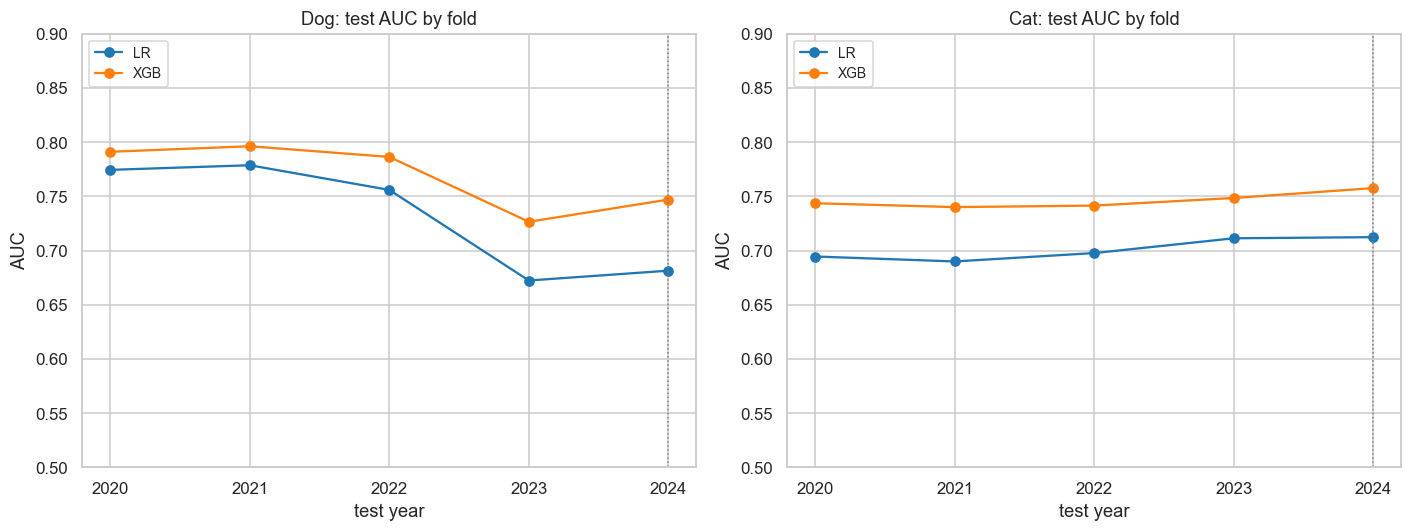

NOTE: dotted line = reference/test fold (2024).


In [13]:
bt = pd.DataFrame(BT)

# ---- HEADLINE: 2024 test fold scored at the §8.1 operating point (top FLAG_RATE by rank) ----
head = []
for sp in ['Dog', 'Cat']:
    for tag in ['LR', 'XGB']:
        yte, pte = BT_PRED[(REF_TEST_YEAR, sp, tag)]
        # the §8.1 operating point: the rolling FLAG_RATE percentile. med_thr is only the median
        # of a moving cut-off, so the flags are passed in rather than recomputed from one value.
        head.append(evaluate(tag, sp, REF_TEST_YEAR, yte, pte,
                             thr=CHOSEN_THR[(sp, tag)], pred=CHOSEN_FLAGS[(sp, tag)]))
        head[-1]['flagged'] = float(np.mean(CHOSEN_FLAGS[(sp, tag)]))
head = (pd.DataFrame(head)[['species', 'model', 'threshold', 'flagged',
                            'recall', 'precision', 'F1', 'AUC', 'n_test']]
          .rename(columns={'threshold': 'med_thr'}))
print(f'HEADLINE — {REF_TEST_YEAR} test fold, flagging the top {FLAG_RATE:.0%} of the trailing '
      f'{WINDOW_DAYS} days (positive class = long-stay):')
print(head.round(3).to_string(index=False))

# ---- AUC stability across folds (threshold-free, supporting evidence) ----
agg = (bt.groupby(['species', 'model'])
         .agg(AUC_mean=('AUC', 'mean'), AUC_std=('AUC', 'std'),
              Brier_mean=('Brier', 'mean'), folds=('AUC', 'size'))
         .round(3))
print(f'\nAUC stability over folds (mean +/- std across test years {TEST_YEARS}; threshold-free):')
print(f'  NOTE: std is computed from {len(TEST_YEARS)} folds — still a small sample, so read it as')
print('  indicative. 2020 and 2021 are trace-only folds: they drive no feature or threshold choice.')
print(agg.to_string())

print('\nPer-fold test AUC (rows = species | model, cols = test year):')
print(bt.pivot_table(index=['species', 'model'], columns='test_year', values='AUC').round(3).to_string())

# AUC trajectory across folds, one panel per species
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, sp in zip(axes, ['Dog', 'Cat']):
    for model, c in [('LR', 'tab:blue'), ('XGB', 'tab:orange')]:
        sub = bt[(bt.species == sp) & (bt.model == model)].sort_values('test_year')
        ax.plot(sub.test_year, sub.AUC, marker='o', label=model, color=c)
    ax.axvline(REF_TEST_YEAR, color='gray', ls=':', lw=1)
    ax.set_title(f'{sp}: test AUC by fold'); ax.set_xlabel('test year'); ax.set_ylabel('AUC')
    ax.set_xticks(TEST_YEARS)  # whole-number years only (no 2020.5-style float ticks)
    ax.set_ylim(0.5, 0.9); ax.legend(fontsize=9)
fig.tight_layout(); plt.show()
print('NOTE: dotted line = reference/test fold (2024).')

### 9.1 Confusion matrices (2024 test fold only)

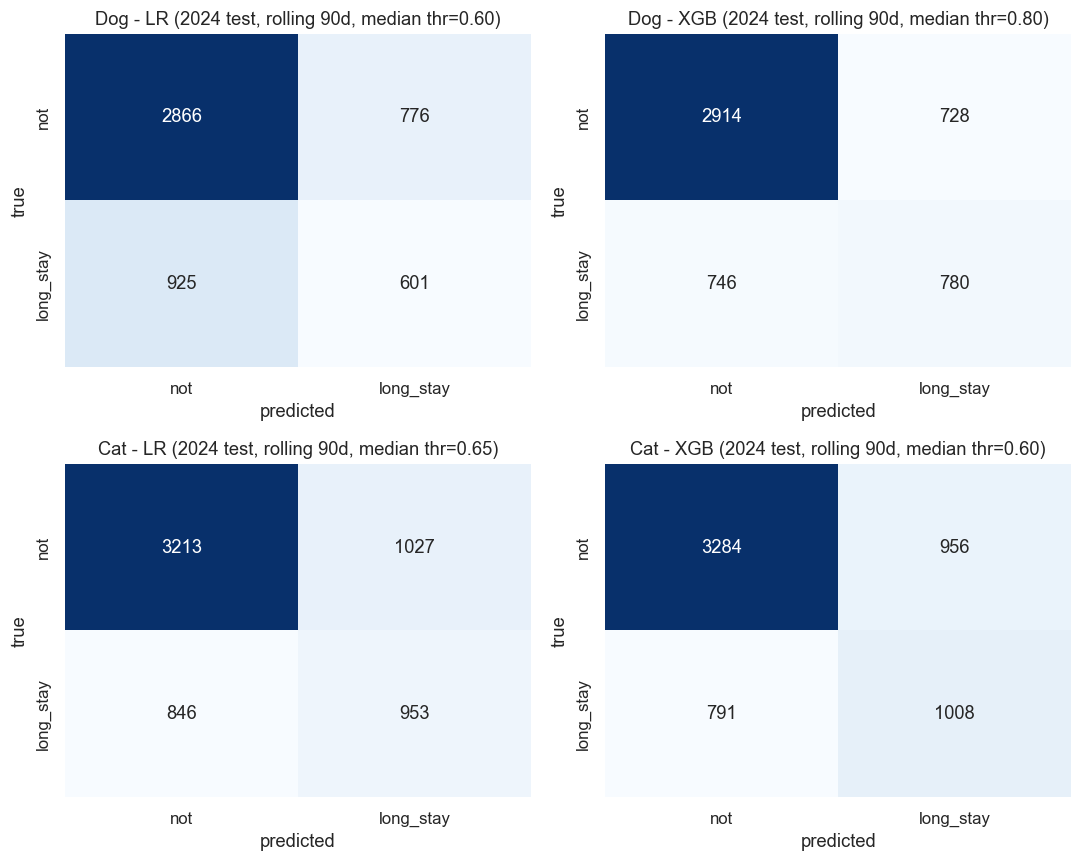

In [14]:
# pool every fold's out-of-sample predictions (each year predicted by a model trained only on its past)
# kept here because §9.2 calibration still pools across all folds; the confusion matrices below use 2024 only.
def pooled(sp, tag):
    ys = np.concatenate([BT_PRED[(Y, sp, tag)][0] for Y in TEST_YEARS])
    ps = np.concatenate([BT_PRED[(Y, sp, tag)][1] for Y in TEST_YEARS])
    return ys, ps

order = [('Dog', 'LR'), ('Dog', 'XGB'), ('Cat', 'LR'), ('Cat', 'XGB')]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (sp, tag) in zip(axes.ravel(), order):
    ys, ps = BT_PRED[(REF_TEST_YEAR, sp, tag)]   # 2024 test fold only (model trained on 2013-2023)
    flags = CHOSEN_FLAGS[(sp, tag)]              # the §8.1 rolling flags, same ones as the §9 headline
    cm = confusion_matrix(ys, flags.astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['not', 'long_stay'], yticklabels=['not', 'long_stay'])
    ax.set_title(f'{sp} - {tag} ({REF_TEST_YEAR} test, rolling {WINDOW_DAYS}d, '
                 f'median thr={CHOSEN_THR[(sp, tag)]:.2f})')
    ax.set_xlabel('predicted'); ax.set_ylabel('true')
fig.tight_layout(); plt.show()

### 9.2 Calibration (reliability), pooled across folds

**Calibration is intentionally distorted.** Per-fold class weighting (LR `class_weight='balanced'`, XGB `scale_pos_weight`) over-weights the minority long-stay class, so predicted probabilities run systematically high and the Brier score / reliability curve look worse than an unweighted fit. This is a **known, accepted cost**: the operating goal needs correct *ranking* (AUC) and the recall/precision the flag rate buys (§8.1), which weighting improves. If trustworthy probabilities are ever needed, fit an isotonic or Platt calibrator on a held-out fold.

`intake_year` makes the dog inflation materially worse — 2024 Brier 0.204 → 0.279, mean predicted probability 0.60 against a true rate of 0.30, and it compounds the further ahead you forecast. It buys ranking at the cost of calibration, which is exactly why §8.1 ranks rather than thresholds: the inflation is a level shift applied to every dog at once, so it leaves the ordering untouched, and the trailing window rises with it. A probability threshold saved from an older build is not comparable to a newer one; a percentile over a trailing window is.

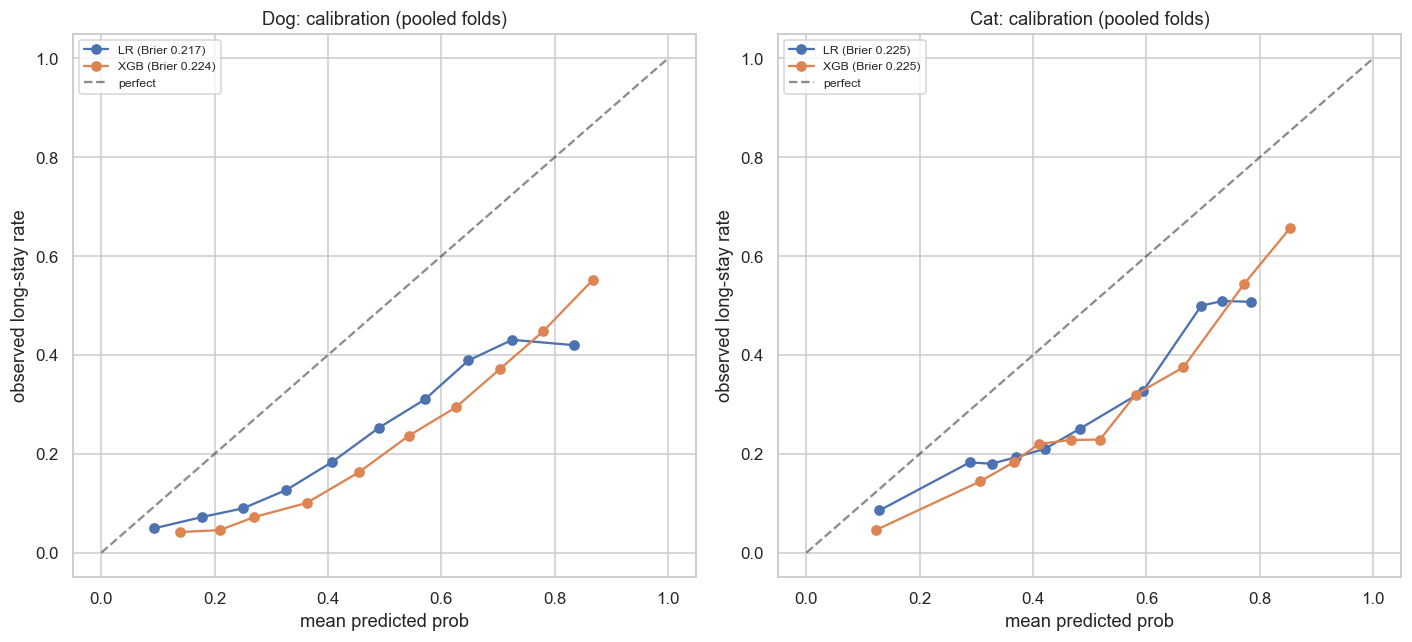

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, sp in zip(axes, ['Dog', 'Cat']):
    for tag in ['LR', 'XGB']:
        ys, ps = pooled(sp, tag)
        frac, mean = calibration_curve(ys, ps, n_bins=10, strategy='quantile')
        ax.plot(mean, frac, marker='o', label=f'{tag} (Brier {brier_score_loss(ys, ps):.3f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='perfect')
    ax.set_title(f'{sp}: calibration (pooled folds)'); ax.set_xlabel('mean predicted prob')
    ax.set_ylabel('observed long-stay rate'); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## 10. Interpretability — what drives long-stay risk (reference-fold models, train ≤ 2023)

Coefficients and SHAP values come from the **reference fold's** fitted models — the ones evaluated on test 2024, with the feature set already locked on the 2022–2023 decision folds (§7). They read the trained model, not the 2024 test labels: one recent, leakage-safe fit rather than an average over folds. **Positive coefficients / SHAP values push toward long stay; negative push away.**

### 10.1 LR coefficients (log-odds; green raises long-stay odds, red lowers them)

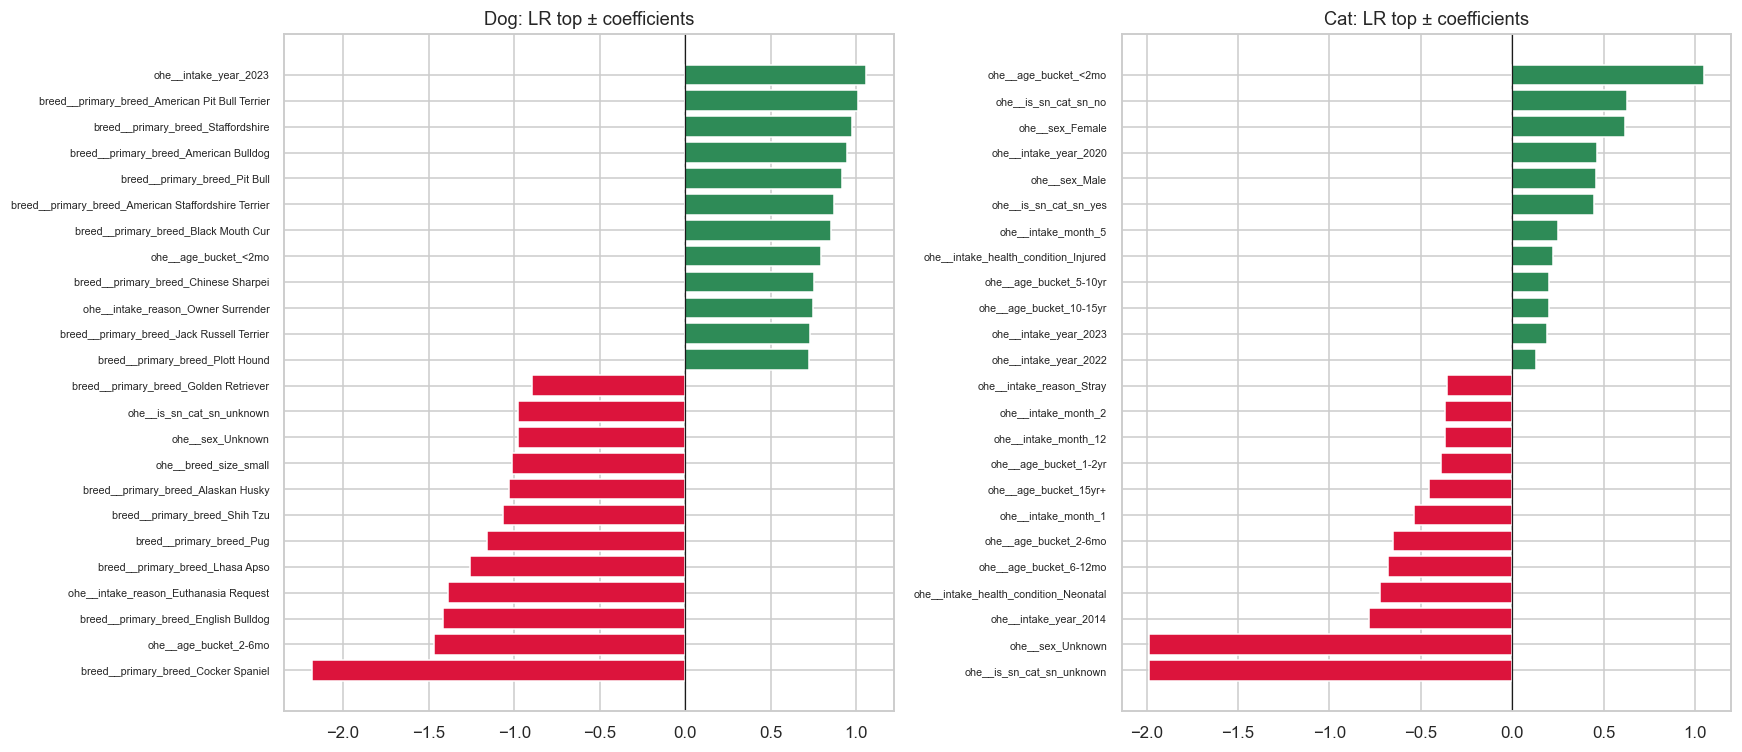

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, sp in zip(axes, ['Dog', 'Cat']):
    pipe = LR_MODELS[sp]
    names = pipe.named_steps['pre'].get_feature_names_out()
    s = pd.Series(pipe.named_steps['clf'].coef_[0], index=names).sort_values()
    top = pd.concat([s.head(12), s.tail(12)])
    ax.barh(range(len(top)), top.values,
            color=['crimson' if v < 0 else 'seagreen' for v in top.values])
    ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=7)
    ax.axvline(0, color='k', lw=0.8); ax.set_title(f'{sp}: LR top ± coefficients')
fig.tight_layout(); plt.show()

### 10.2 XGBoost SHAP (computed on TRAIN; not impurity importance, which is biased toward high-cardinality features) — positive SHAP pushes toward long stay

/var/folders/xv/__dg3mss3f1d57y41qhwz0dh0000gn/T/ipykernel_94573/1372375209.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Z, feature_names=names, max_display=15, show=False)


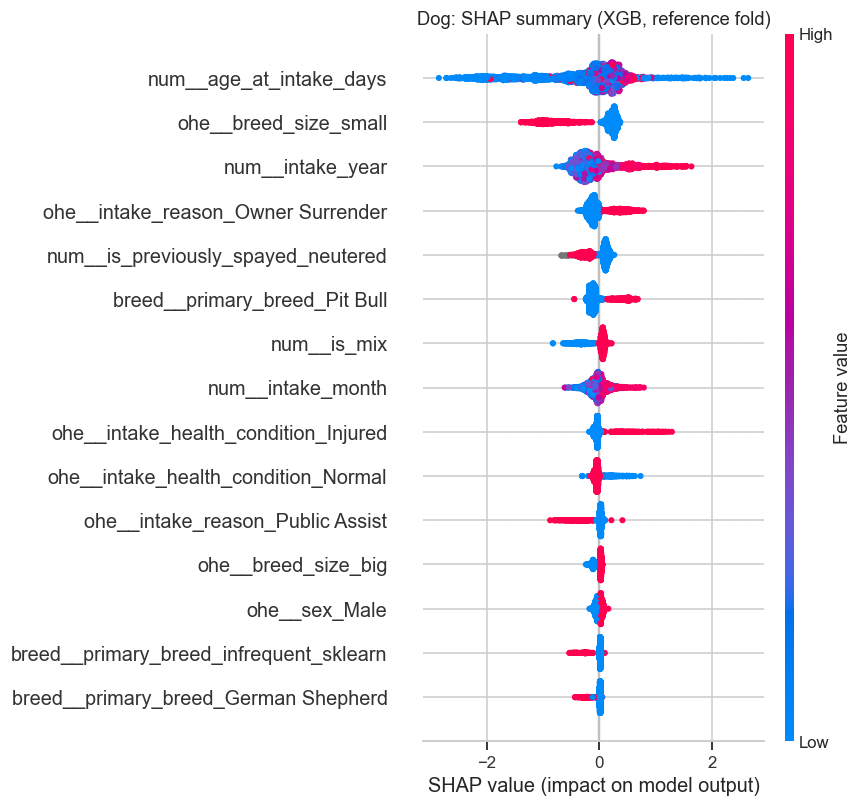

/var/folders/xv/__dg3mss3f1d57y41qhwz0dh0000gn/T/ipykernel_94573/1372375209.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Z, feature_names=names, max_display=15, show=False)


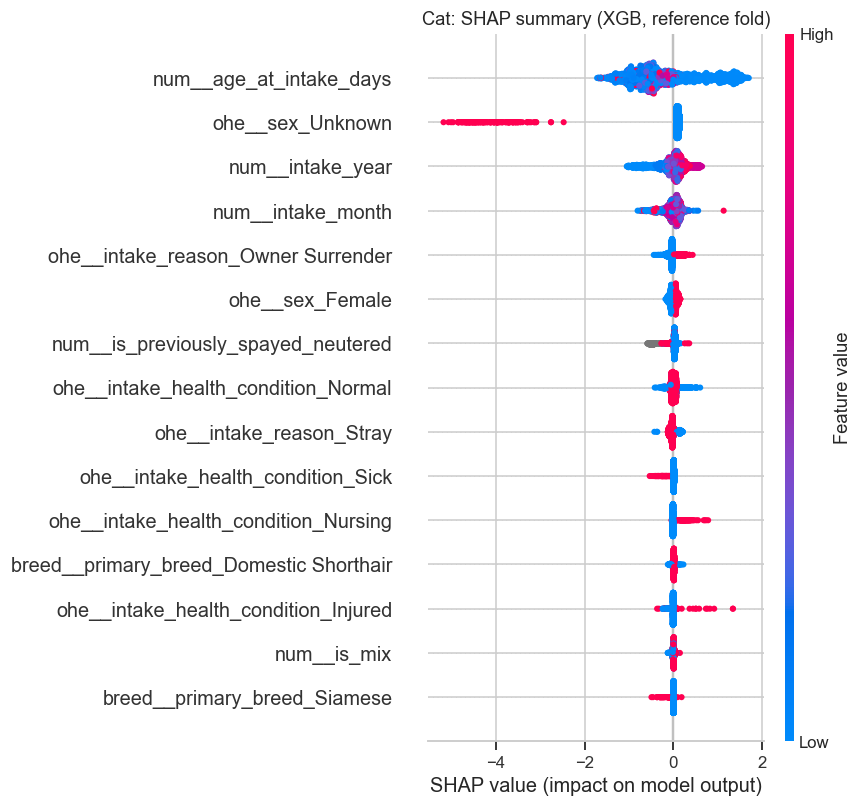

In [17]:
SHAP_INFO = {}
for sp in ['Dog', 'Cat']:
    pre, final = XGB_MODELS[sp]
    names = list(pre.get_feature_names_out())
    samp = REF_TR[sp].sample(min(2500, len(REF_TR[sp])), random_state=RANDOM_STATE)
    Z = pre.transform(samp)
    sv = shap.TreeExplainer(final).shap_values(Z)
    SHAP_INFO[sp] = (names, np.abs(sv).mean(0))
    plt.figure()
    shap.summary_plot(sv, Z, feature_names=names, max_display=15, show=False)
    plt.title(f'{sp}: SHAP summary (XGB, reference fold)'); plt.tight_layout(); plt.show()

## 11. Export the headline model (reference fold — train ≤ 2023, test 2024)

**XGBoost is the headline model:** it beats the LR baseline on the 2024 test fold for both species (Dog AUC 0.747 vs 0.681, Cat 0.758 vs 0.712) and it is the fit §10 interprets. What gets written to disk is the **same fitted object §8 evaluated** — `XGB_MODELS[sp]`, trained on `intake_year ≤ 2023` — nothing is refit, so the artifact's scores *are* the reported ones, and the 2024 labels stayed out of every choice baked into it.

One bundle **per species** (rule 1 — never pooled), each holding:

| key | what it is |
|---|---|
| `pipeline` | the fold-fitted `ColumnTransformer` → `XGBClassifier`, so `predict_proba` takes a **raw intake dataframe** |
| `threshold` | the §8.1 **rule** (`flag_rate`, `window_days`) plus the median of the moving cut-off. The median is a diagnostic — **do not apply it as a constant** |
| `card` | fold, test metrics, feature set, input contract, hyperparameters, library versions |

Two sidecars per species: `*_booster.json` (the booster in XGBoost's **native** format, which survives library upgrades that break a pickle) and `*_card.json` (the card alone). The LR baseline is deliberately **not** exported — it is the comparison, not the deliverable.

```python
import joblib, numpy as np
b = joblib.load('models/long_stay_xgb_dog_2024.joblib')
rate = b['card']['threshold']['flag_rate']       # 0.30
win  = b['card']['threshold']['window_days']     # 90

proba  = b['pipeline'].predict_proba(new_intakes)[:, 1]   # raw columns, §3 prep applied (see card)
recent = scores_of_intakes_in_the_last(win)               # scores you already computed, past `win` days
flag   = proba >= np.quantile(recent, 1 - rate)           # top 30% of the trailing window
```

If you score in batches instead of one animal at a time, take the percentile of the batch — weekly batches reproduce the rolling numbers to within 0.01.

**Deployment caveat (§9.2):** class weighting distorts calibration, so use the model's **ranking**, never the raw probability. Recompute the trailing percentile every time you score, and re-check the ranking against fresh years given the dog-side drift in Appendix 1.

In [18]:
# Export is ON: ../models/ is written from the SAME fitted objects §8 evaluated, so the artefacts
# match the numbers above (current feature set, 5-fold backtest, FLAG_RATE operating point).
# ../models/ is gitignored — these files are local and regenerable by re-running this notebook.
EXPORT_MODELS = True

if not EXPORT_MODELS:
    print('Model export SKIPPED (EXPORT_MODELS=False) — ../models/ keeps whatever is already there.')
else:
    # ---------------- export the headline model: XGB, reference-fold fit (train <= 2023), one bundle per species ----------------
    import sys, json, joblib, sklearn, xgboost
    from pathlib import Path
    from datetime import date

    HEADLINE_ALGO = 'XGB'                      # §9: XGB beats the LR baseline on the 2024 test fold, both species
    MODEL_DIR = Path('../models'); MODEL_DIR.mkdir(parents=True, exist_ok=True)

    def xgb_input_cols(pre):
        """Raw columns the FITTED preprocessor actually reads (§6) — the input contract for scoring
        new intakes. Read off the transformer rather than hand-listed, so it cannot drift from the
        model: dogs carry breed_size, cats do not, and both need intake_month / intake_year."""
        cols = [c for name, _, sel in pre.transformers_ if name != 'remainder'
                for c in (sel if isinstance(sel, list) else [])]
        return sorted(set(cols))

    for sp in ['Dog', 'Cat']:
        pre, final = XGB_MODELS[sp]            # fitted in §8 on REF_TR[sp] (intake_year <= 2023) — NOT refit here
        pipe = Pipeline([('pre', pre), ('clf', final)])   # wrap the already-fitted steps: raw frame -> proba
        thr  = CHOSEN_THR[(sp, HEADLINE_ALGO)]
        yte, pte = BT_PRED[(REF_TEST_YEAR, sp, HEADLINE_ALGO)]
        m = evaluate(HEADLINE_ALGO, sp, REF_TEST_YEAR, yte, pte,
                     thr=thr, pred=CHOSEN_FLAGS[(sp, HEADLINE_ALGO)])
        hp = final.get_params()

        card = {
            'name': f'long_stay_xgb_{sp.lower()}_{REF_TEST_YEAR}',
            'created': date.today().isoformat(),
            'species': sp,
            'algorithm': 'sklearn Pipeline: ColumnTransformer (one-hot + top-N breed + raw numerics) -> XGBClassifier',
            'target': {'column': TARGET, 'definition': 'length_of_stay_days > 30',
                       'positive_class': 'long stay (> 30 days)'},
            'fold': {'role': 'reference fold — headline test fold + §10 interpretability',
                     'train_years': f'{int(REF_TR[sp].intake_year.min())}-{int(REF_TR[sp].intake_year.max())}',
                     'n_train': int(len(REF_TR[sp])),
                     'train_long_stay_rate': round(float(REF_TR[sp][TARGET].mean()), 4),
                     'test_year': int(REF_TEST_YEAR), 'n_test': int(m['n_test'])},
            'threshold': {'value': round(float(thr), 4),
                          'rule': f'flag when the score is in the top {FLAG_RATE:.0%} of everything scored in '
                                  f'the previous {WINDOW_DAYS} days',
                          'flag_rate': FLAG_RATE,
                          'window_days': WINDOW_DAYS,
                          'caveat': 'value is only the MEDIAN of a moving threshold, kept as a diagnostic. Do not '
                                    'apply it as a constant: recompute the percentile over the trailing window '
                                    'each time you score, since probabilities inflate across years (§9.2)'},
            'test_metrics': {k: round(float(m[k]), 4) for k in ['AUC', 'precision', 'recall', 'F1', 'Brier']},
            'features': FEATURES[sp],
            'input_columns': xgb_input_cols(pre),
            'required_preprocessing': {
                'intake_health_condition': f'keep {HEALTH_KEEP}, fold every other level into "Other" (§3)',
                'sex, intake_reason': 'fillna("Unknown") (§3)',
                'primary_breed': f'raw string; the fitted encoder keeps the train top-{BREED_TOPN[sp]} and sends '
                                 'everything else — including breeds unseen in training — to the infrequent bucket',
                'age_at_intake_days': 'age in days as a number; NaN is fine (XGB handles missing natively)',
                'is_mix, is_previously_spayed_neutered': '0/1; NaN is fine',
            },
            'hyperparameters': {k: hp[k] for k in ['n_estimators', 'max_depth', 'learning_rate', 'subsample',
                                                   'colsample_bytree', 'scale_pos_weight', 'tree_method',
                                                   'eval_metric', 'random_state']},
            'never_used_as_features': LEAKAGE_COLS,
            'versions': {'python': sys.version.split()[0], 'scikit-learn': sklearn.__version__,
                         'xgboost': xgboost.__version__, 'pandas': pd.__version__, 'numpy': np.__version__,
                         'joblib': joblib.__version__},
        }

        stem   = MODEL_DIR / card['name']
        bundle = stem.with_suffix('.joblib')
        joblib.dump({'pipeline': pipe, 'threshold': float(thr), 'card': card}, bundle)
        final.get_booster().save_model(f'{stem}_booster.json')   # native format: survives pickle-breaking upgrades
        Path(f'{stem}_card.json').write_text(json.dumps(card, indent=2, default=str))

        # reload check: the saved artifact must reproduce the exact 2024 test-fold probabilities reported in §9
        back = joblib.load(bundle)['pipeline'].predict_proba(REF_TE[sp])[:, 1]
        assert np.allclose(back, pte), f'{sp}: reloaded pipeline does not reproduce the reference-fold probabilities'
        print(f'{sp:3} -> {bundle.name}  ({bundle.stat().st_size / 1024:.0f} KB, thr={thr:.3f}, '
              f"test {REF_TEST_YEAR}: AUC={m['AUC']:.3f} F1={m['F1']:.3f})  reload check OK")

    print(f'\nsaved to {MODEL_DIR}/ — per species: bundle (.joblib) + native booster (_booster.json) '
          '+ model card (_card.json)')

Dog -> long_stay_xgb_dog_2024.joblib  (678 KB, thr=0.797, test 2024: AUC=0.747 F1=0.514)  reload check OK
Cat -> long_stay_xgb_cat_2024.joblib  (854 KB, thr=0.597, test 2024: AUC=0.758 F1=0.536)  reload check OK

saved to ../models/ — per species: bundle (.joblib) + native booster (_booster.json) + model card (_card.json)


### Appendix 1 — why dog AUC dropped in 2023

Dog XGB held **0.791 / 0.796 / 0.786** across the 2020–2022 folds, then fell to **0.727** in 2023 (0.747 in 2024); cats stayed flat at 0.740–0.758 throughout. This appendix narrows the cause by elimination — each section rules something out.

| § | question | verdict |
|---|---|---|
| A1.1 | did the base-rate jump cause it? | **ruled out** — AUC is base-rate invariant |
| A1.2 | is the model merely stale? | **partly ruled out** — an oracle that has seen 2023 still drops |
| A1.3 | what concretely got worse? | the two score distributions compressed, at the low-risk end |
| A1.4 | which outcome pathway slowed? | **adoption only** — transfer got *faster* |
| A1.5 | why does it look like a size effect? | proportional slowdown × a fixed 30-day cut-off |
| A1.6 | what is still unexplained? | *why* adoption slowed — not answerable from this data |

In [19]:
# ===== A1.1 — can a base-rate jump lower AUC? =====
# Direct test: take the 2022 dog fold's out-of-sample predictions and randomly drop negatives until
# the positive rate matches 2023's. The RANKING is untouched — only the class mix changes.
rng = np.random.default_rng(RANDOM_STATE)
_y22, _p22 = BT_PRED[(2022, 'Dog', 'XGB')]
_y22 = np.asarray(_y22); _p22 = np.asarray(_p22)
_rate22 = _y22.mean()
_rate23 = df[(df.animal_type == 'Dog') & (df.intake_year == 2023)][TARGET].mean()

_pos = np.flatnonzero(_y22 == 1); _neg = np.flatnonzero(_y22 == 0)
_keep_neg = int(round(len(_pos) * (1 - _rate23) / _rate23))     # negatives to keep to hit 2023's rate
_aucs = []
for _ in range(200):
    _idx = np.concatenate([_pos, rng.choice(_neg, size=min(_keep_neg, len(_neg)), replace=False)])
    _aucs.append(roc_auc_score(_y22[_idx], _p22[_idx]))

print('A1.1 — AUC is invariant to the base rate')
print(f'  2022 dog fold as observed : rate {_rate22:.3f}  AUC {roc_auc_score(_y22, _p22):.3f}')
print(f'  same predictions, negatives thinned to 2023\'s rate {_rate23:.3f}:')
print(f'                              AUC {np.mean(_aucs):.3f} +/- {np.std(_aucs):.3f}  (200 resamples)')
print('  => forcing 2022 to have 2023\'s positive rate leaves AUC where it was.')
print('     The base-rate jump therefore CANNOT be the cause of the AUC drop. Something else changed.')

A1.1 — AUC is invariant to the base rate
  2022 dog fold as observed : rate 0.219  AUC 0.786
  same predictions, negatives thinned to 2023's rate 0.315:
                              AUC 0.786 +/- 0.003  (200 resamples)
  => forcing 2022 to have 2023's positive rate leaves AUC where it was.
     The base-rate jump therefore CANNOT be the cause of the AUC drop. Something else changed.


In [20]:
# ===== A1.2 — is the model stale, or did the data get harder? =====
# A bad walk-forward score has two possible causes: the model is out of date (fixable by
# retraining) or the features stopped explaining the target (not fixable). An in-year oracle
# separates them — 5-fold CV inside ONE year, so staleness is zero by construction.
from sklearn.model_selection import StratifiedKFold

def in_year_oracle(sp, year, n_splits=5):
    s = df[(df.animal_type == sp) & (df.intake_year == year)]
    y = s[TARGET].to_numpy()
    aucs = []
    for tr_i, te_i in StratifiedKFold(n_splits, shuffle=True, random_state=RANDOM_STATE).split(s, y):
        tr, te = s.iloc[tr_i], s.iloc[te_i]
        pipe = Pipeline([('pre', make_preprocessor('xgb', sp)),
                         ('clf', XGBClassifier(n_estimators=400, max_depth=3, learning_rate=0.05,
                                               subsample=0.9, colsample_bytree=0.9, tree_method='hist',
                                               eval_metric='auc', scale_pos_weight=_spw(tr),
                                               n_jobs=4, random_state=RANDOM_STATE))])
        pipe.fit(tr, tr[TARGET])
        aucs.append(roc_auc_score(te[TARGET], pipe.predict_proba(te)[:, 1]))
    return float(np.mean(aucs))

_wf = bt[bt.model == 'XGB'].set_index(['species', 'test_year']).AUC
oracle = pd.DataFrame([
    dict(species=sp, year=Y, oracle_AUC=round(o := in_year_oracle(sp, Y), 3),
         walkforward_AUC=round(w := float(_wf.loc[(sp, Y)]), 3), staleness_gap=round(o - w, 3))
    for sp in ['Dog', 'Cat'] for Y in TEST_YEARS])
print('A1.2 — in-year oracle (same-year train/test => no staleness) vs walk-forward\n')
print(oracle.to_string(index=False))

_o = oracle[oracle.species == 'Dog'].set_index('year')
_dor = _o.loc[2023, 'oracle_AUC'] - _o.loc[2022, 'oracle_AUC']
_dwf = _o.loc[2023, 'walkforward_AUC'] - _o.loc[2022, 'walkforward_AUC']
print(f'\nDog 2022->2023: oracle {_dor:+.3f} vs walk-forward {_dwf:+.3f}. So {_dor/_dwf:.0%} of the drop')
print(f'survives a model that HAS seen 2023 = signal loss; the other {1-_dor/_dwf:.0%} is staleness.')

A1.2 — in-year oracle (same-year train/test => no staleness) vs walk-forward

species  year  oracle_AUC  walkforward_AUC  staleness_gap
    Dog  2020       0.816            0.791          0.025
    Dog  2021       0.825            0.796          0.029
    Dog  2022       0.818            0.786          0.032
    Dog  2023       0.773            0.727          0.047
    Dog  2024       0.783            0.747          0.036
    Cat  2020       0.795            0.744          0.051
    Cat  2021       0.797            0.740          0.057
    Cat  2022       0.782            0.741          0.040
    Cat  2023       0.784            0.749          0.035
    Cat  2024       0.788            0.758          0.031

Dog 2022->2023: oracle -0.045 vs walk-forward -0.059. So 76% of the drop
survives a model that HAS seen 2023 = signal loss; the other 24% is staleness.


In [21]:
# ===== A1.3 — what concretely got worse? =====
# AUC = P(a long-stay dog scores above a fast one). So a drop means the two score distributions
# moved together. Score 2022 and 2023 with ONE model (trained <=2021) so the scale is comparable.
_tr = df[(df.animal_type == 'Dog') & (df.intake_year <= 2021)]
_m = Pipeline([('pre', make_preprocessor('xgb', 'Dog')),
               ('clf', XGBClassifier(n_estimators=400, max_depth=3, learning_rate=0.05,
                                     subsample=0.9, colsample_bytree=0.9, tree_method='hist',
                                     eval_metric='auc', scale_pos_weight=_spw(_tr),
                                     n_jobs=4, random_state=RANDOM_STATE))]).fit(_tr, _tr[TARGET])

_S = {Y: (s := df[(df.animal_type == 'Dog') & (df.intake_year == Y)],
          _m.predict_proba(s)[:, 1]) for Y in [2022, 2023]}
print('A1.3 — the gap between the two groups\' mean scores')
for Y, (s, sc) in _S.items():
    pos, neg = sc[s[TARGET] == 1], sc[s[TARGET] == 0]
    print(f'  {Y}: long-stay {pos.mean():.3f} | fast {neg.mean():.3f} | '
          f'gap {pos.mean()-neg.mean():+.3f} | AUC {roc_auc_score(s[TARGET], sc):.3f}')
print("2023's long-stay dogs score LOWER than 2022's — they look more like fast dogs.")

# where the extra long stays landed, by the model's own confidence (quartiles pooled over both years)
_edges = np.quantile(np.concatenate([_S[2022][1], _S[2023][1]]), [0, .25, .5, .75, 1.0])
print('\nlong-stay rate by model risk quartile:')
for k, lab in enumerate(['lowest risk 25%', 'Q2', 'Q3', 'highest risk 25%']):
    r = {Y: s[TARGET][(sc >= _edges[k]) & (sc <= _edges[k+1])].mean() for Y, (s, sc) in _S.items()}
    print(f'  {lab:<18} {r[2022]:.3f} -> {r[2023]:.3f}   ({r[2023]/r[2022]:.1f}x)')
print('Ceiling effect: the top quartile was already ~0.48 with nowhere to go, the bottom was 0.030')
print('with room to quadruple. A shelter-wide shock therefore COMPRESSES the gap that AUC measures.')

A1.3 — the gap between the two groups' mean scores
  2022: long-stay 0.630 | fast 0.380 | gap +0.250 | AUC 0.796
  2023: long-stay 0.582 | fast 0.409 | gap +0.173 | AUC 0.705
2023's long-stay dogs score LOWER than 2022's — they look more like fast dogs.

long-stay rate by model risk quartile:
  lowest risk 25%    0.030 -> 0.125   (4.1x)
  Q2                 0.106 -> 0.206   (1.9x)
  Q3                 0.287 -> 0.384   (1.3x)
  highest risk 25%   0.484 -> 0.510   (1.1x)
Ceiling effect: the top quartile was already ~0.48 with nowhere to go, the bottom was 0.030
with room to quadruple. A shelter-wide shock therefore COMPRESSES the gap that AUC measures.


In [22]:
# ===== A1.4 — which outcome pathway slowed? =====
# If the shelter had simply seized up, every exit route would slow together. Testing that gives
# the diagnosis a control group. Still-in-shelter rows are excluded: their LOS is a censored bound.
_d = df[(df.animal_type == 'Dog') & (df.outcome_category != 'still in shelter')].copy()
_d['length_of_stay_days'] = pd.to_numeric(_d['length_of_stay_days'], errors='coerce')
_d = _d[_d.intake_year.between(2021, 2024) & _d.length_of_stay_days.notna()]

_sh = _d.pivot_table(index='outcome_type', columns='intake_year', values=TARGET, aggfunc='size')
_sh = (_sh / _sh.sum()).round(3)
_keep = _sh[_sh.max(axis=1) > 0.01].index          # ignore pathways under 1% (noise)
_med = _d[_d.outcome_type.isin(_keep)].pivot_table(index='outcome_type', columns='intake_year',
                                                   values='length_of_stay_days', aggfunc='median')
print('A1.4 — median days to exit, by pathway'); print(_med.to_string())
print('\nshare of exits:'); print(_sh.loc[_keep].to_string())
print('\nAdoption median nearly doubled (14->27d); TRANSFER GOT FASTER, return-to-owner flat.')
print('A general shelter jam cannot produce that pattern — the slowdown is adoption-specific.')

# mix vs speed: did the pathway mix shift, or did each pathway itself slow?
_w22, _w23 = _sh.loc[_keep, 2022], _sh.loc[_keep, 2023]
_m22, _m23 = _med[2022], _med[2023]
_base, _mix, _full = (_w22*_m22).sum(), (_w23*_m22).sum(), (_w23*_m23).sum()
print(f'\nweighted median {_base:.1f}d -> {_full:.1f}d  =  mix {_mix-_base:+.1f}d '
      f'({(_mix-_base)/(_full-_base):.0%}) + per-pathway slowdown {_full-_mix:+.1f}d '
      f'({(_full-_mix)/(_full-_base):.0%})')
_c = df[(df.animal_type == 'Cat') & (df.outcome_type == 'Adoption')].copy()
_c['length_of_stay_days'] = pd.to_numeric(_c['length_of_stay_days'], errors='coerce')
print('cat adoption median, 2021-2024:',
      _c[_c.intake_year.between(2021, 2024)].groupby('intake_year').length_of_stay_days.median().to_dict())
print('CAVEAT: this median conditions on dogs that were ultimately adopted. Transfer share fell')
print('(0.267->0.211) so some fast-transfer dogs moved into the slower adoption route, inflating it.')

A1.4 — median days to exit, by pathway
intake_year      2021  2022  2023  2024
outcome_type                           
Adoption         11.0  14.0  27.0  18.0
Euthanasia        4.0   4.0   7.5   8.0
Return to Owner   1.0   1.0   2.0   2.0
Rto-Adopt         7.0  10.0  12.0   8.0
Transfer          6.0   7.0   4.0   4.0

share of exits:
intake_year       2021   2022   2023   2024
outcome_type                               
Adoption         0.571  0.545  0.611  0.648
Euthanasia       0.014  0.015  0.015  0.024
Return to Owner  0.171  0.147  0.136  0.133
Rto-Adopt        0.017  0.019  0.016  0.020
Transfer         0.220  0.267  0.211  0.164

Adoption median nearly doubled (14->27d); TRANSFER GOT FASTER, return-to-owner flat.
A general shelter jam cannot produce that pattern — the slowdown is adoption-specific.

weighted median 9.9d -> 17.9d  =  mix +0.5d (6%) + per-pathway slowdown +7.5d (94%)
cat adoption median, 2021-2024: {2021: 20.0, 2022: 22.0, 2023: 26.0, 2024: 25.0}
CAVEAT: this medi

In [23]:
# ===== A1.5 — why it LOOKS like a big-dog problem: adoption waits vs the 30-day line =====
_ad = _d[_d.outcome_type == 'Adoption']
print('A1.5 — median days to adoption, by breed_size')
print(_ad[_ad.breed_size.isin(['small', 'big'])]
      .pivot_table(index='breed_size', columns='intake_year',
                   values='length_of_stay_days', aggfunc='median').to_string())
print('Both sizes slowed by the SAME factor (~1.9x). Size is not the axis the shock travelled along')
print('— it sets how close you already were to the 30-day line. Big: 16->30 lands right ON it.')

_g = _d.groupby('intake_year')['length_of_stay_days']
_dist = pd.DataFrame({'LOS_median': _g.median(), 'LOS_p75': _g.quantile(.75),
                      'long_stay_rate': _d.groupby('intake_year')[TARGET].mean().round(3)})
for lo, hi, lab in [(0, 20, 'pct_under_21d'), (21, 45, 'pct_21_45d_BOUNDARY'), (46, 10**9, 'pct_over_45d')]:
    _dist[lab] = _g.apply(lambda s: ((s >= lo) & (s <= hi)).mean()).round(3)
print('\n' + _dist.round(2).to_string())
print('The band straddling the cut-off thickened — labels there turn on a few days of luck.')

# constant-base-rate control: does 2023 still lag when the positive rate is pinned at 30%?
print('\nin-year AUC on a relative label (top 30% longest stays within each year):')
for Y in [y for y in TEST_YEARS if y in set(_d.intake_year)]:
    s = _d[_d.intake_year == Y].copy()
    s['_yr'] = (s.length_of_stay_days > s.length_of_stay_days.quantile(0.70)).astype(int)
    a = []
    for tr_i, te_i in StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE).split(s, s._yr):
        tr, te = s.iloc[tr_i], s.iloc[te_i]
        w = int((tr._yr == 0).sum()) / max(int((tr._yr == 1).sum()), 1)
        pipe = Pipeline([('pre', make_preprocessor('xgb', 'Dog')),
                         ('clf', XGBClassifier(n_estimators=400, max_depth=3, learning_rate=0.05,
                                               subsample=0.9, colsample_bytree=0.9, tree_method='hist',
                                               eval_metric='auc', scale_pos_weight=w, n_jobs=4,
                                               random_state=RANDOM_STATE))]).fit(tr, tr['_yr'])
        a.append(roc_auc_score(te['_yr'], pipe.predict_proba(te)[:, 1]))
    print(f'  {Y}: {np.mean(a):.3f}')
print('2023 still lags with the base rate pinned: the cut-off amplifies a real change, it does not')
print('manufacture one. breed_size is kept, but it earns -0.002/+0.007/+0.009 AUC by fold, not ~+0.02.')

A1.5 — median days to adoption, by breed_size
intake_year  2021  2022  2023  2024
breed_size                         
big          12.0  16.0  30.0  23.0
small         6.5   7.0  13.0   7.0
Both sizes slowed by the SAME factor (~1.9x). Size is not the axis the shock travelled along
— it sets how close you already were to the 30-day line. Big: 16->30 lands right ON it.

             LOS_median  LOS_p75  long_stay_rate  pct_under_21d  pct_21_45d_BOUNDARY  pct_over_45d
intake_year                                                                                       
2021                7.0     19.0            0.18           0.77                 0.12          0.12
2022                8.0     26.0            0.22           0.72                 0.13          0.16
2023               14.0     40.0            0.32           0.59                 0.19          0.22
2024               11.0     35.0            0.28           0.64                 0.16          0.20
The band straddling the cut-off th

  2021: 0.805


  2022: 0.805


  2023: 0.779


  2024: 0.774
2023 still lags with the base rate pinned: the cut-off amplifies a real change, it does not
manufacture one. breed_size is kept, but it earns -0.002/+0.007/+0.009 AUC by fold, not ~+0.02.


### A1.6 — what the evidence does and does not support

| claim | status |
|---|---|
| AUC is invariant to the base rate | ✅ measured by resampling (A1.1) |
| Not merely a stale model | ✅ in-year oracle (A1.2) |
| The two score distributions compressed, at the low-risk end | ✅ A1.3 |
| Adoption slowed; it was **not** a general shelter jam | ✅ A1.4 — transfer got *faster*, which falsifies the jam |
| A proportional slowdown × a fixed cut-off looks like a size effect | ✅ A1.5 |
| **Why adoption slowed** — fewer adopters? more competition? policy change? | ❌ **not answerable here** — no adopter counts, foot traffic, listing dates or policy records in this export |

The chain narrows "what happened in 2023" to "the adoption route slowed ~1.9x for every size of dog". The remaining step needs data this export does not contain.

### Appendix 2 — is the XGBoost depth grid wide enough?

§8 tunes `max_depth` over **{3, 5}** and both species select **5** — the *top* of the grid. A boundary selection establishes only that "5 beats 3", never that 5 is best: the optimum may sit outside the grid entirely. The exported boosters sharpen the doubt — every tree in them has realized depth exactly 5 (min = max = 5), so the **cap**, not the data, is what stops them growing.

This appendix widens the grid to **{3, 5, 7, 9}** and re-runs all five folds, reusing §6/§8's own `make_preprocessor`, `_spw` and `fold_frames` so the numbers stay comparable to the backtest. Selection uses the same inner-validation year §8 uses (the last training year); the test year is scored for reporting and never selects anything.

| § | question | verdict |
|---|---|---|
| A2.1 | does a deeper tree win once the grid is widened? | **no** — depth 5 is best for both species on inner validation |

In [ ]:
# ===== A2.1 — is the tuning grid wide enough? Sweep depth {3, 5, 7, 9} on every fold =====

import json

A2_DEPTHS, A2_LRS = [3, 5, 7, 9], [0.03, 0.1]

def tree_shapes(model):
    """(depth, n_leaves) for every tree, by DFS over the flat child arrays (leaf => child == -1).
    max_depth is only a CEILING, so what the trees actually grew to has to be measured, not read
    off the config."""
    trees = json.loads(bytes(model.get_booster().save_raw(raw_format='json')))[
        'learner']['gradient_booster']['model']['trees']
    out = []
    for t in trees:
        lc = [int(x) for x in t['left_children']]
        rc = [int(x) for x in t['right_children']]
        d, stack = 0, [(0, 0)]
        while stack:
            n, k = stack.pop()
            if lc[n] == -1:
                d = max(d, k); continue
            stack.append((lc[n], k + 1)); stack.append((rc[n], k + 1))
        out.append((d, sum(1 for x in lc if x == -1)))
    return out

A2 = []
for Y in TEST_YEARS:
    tr_all, te_all = fold_frames(Y)
    for sp in ['Dog', 'Cat']:
        tr, te = tr_all[tr_all.animal_type == sp], te_all[te_all.animal_type == sp]
        # identical inner split / encoders / class weights to tune_and_fit_xgb (§8)
        val_year = sorted(tr.intake_year.unique())[-1]
        inner_tr, inner_val = tr[tr.intake_year < val_year], tr[tr.intake_year == val_year]
        pre = make_preprocessor('xgb', sp)
        Ztr, Zval = pre.fit_transform(inner_tr), pre.transform(inner_val)
        pre2 = make_preprocessor('xgb', sp)      # refit on the FULL fold-train, as §8 does
        Zfull, Zte = pre2.fit_transform(tr), pre2.transform(te)
        spw_inner, spw_full = _spw(inner_tr), _spw(tr)
        for depth in A2_DEPTHS:
            for lr in A2_LRS:
                m = XGBClassifier(n_estimators=800, max_depth=depth, learning_rate=lr,
                                  subsample=0.9, colsample_bytree=0.9, eval_metric='auc',
                                  early_stopping_rounds=30, tree_method='hist',
                                  scale_pos_weight=spw_inner, n_jobs=4, random_state=RANDOM_STATE)
                m.fit(Ztr, inner_tr[TARGET], eval_set=[(Zval, inner_val[TARGET])], verbose=False)
                best_n = int(m.best_iteration) + 1
                final = XGBClassifier(n_estimators=best_n, max_depth=depth, learning_rate=lr,
                                      subsample=0.9, colsample_bytree=0.9, eval_metric='auc',
                                      tree_method='hist', scale_pos_weight=spw_full,
                                      n_jobs=4, random_state=RANDOM_STATE)
                final.fit(Zfull, tr[TARGET])
                shapes = tree_shapes(final)
                A2.append(dict(test_year=Y, species=sp, depth=depth, lr=lr,
                               inner_val_auc=float(m.best_score), n_trees=best_n,
                               test_auc=roc_auc_score(te[TARGET].values,
                                                      final.predict_proba(Zte)[:, 1]),
                               min_depth=min(d for d, _ in shapes),
                               max_depth_seen=max(d for d, _ in shapes),
                               mean_leaves=float(np.mean([l for _, l in shapes]))))
    print(f'  ...A2 sweep fold {Y} done')
A2 = pd.DataFrame(A2)

# fidelity: the depth-5 cells must reproduce §8's chosen models, or nothing below is comparable
_chk = A2[(A2.test_year == REF_TEST_YEAR) & (A2.depth == 5)].set_index(['species', 'lr'])
print(f'\nfidelity vs §8 ({REF_TEST_YEAR} fold, depth 5): '
      f"Dog lr=0.1 -> {_chk.loc[('Dog', 0.1), 'n_trees']:.0f} trees / AUC "
      f"{_chk.loc[('Dog', 0.1), 'test_auc']:.4f} | "
      f"Cat lr=0.03 -> {_chk.loc[('Cat', 0.03), 'n_trees']:.0f} trees / AUC "
      f"{_chk.loc[('Cat', 0.03), 'test_auc']:.4f}   (§11 cards: 285/0.7470 and 348/0.7576)")

# which depth the tuner WOULD pick per fold — inner validation only, exactly as §8 selects
sel = A2.loc[A2.groupby(['species', 'test_year'])['inner_val_auc'].idxmax()]
print(f'\nDepth selected per fold (by inner-validation AUC, the §8 criterion):')
print(sel[['species', 'test_year', 'depth', 'lr', 'inner_val_auc', 'test_auc']]
      .round(4).to_string(index=False))
print('\nselected depth, counted over the 10 fold-species:',
      sel.depth.value_counts().sort_index().to_dict())

# best lr within each (fold, depth), then averaged over folds — how depths actually compare
_best = A2.loc[A2.groupby(['species', 'test_year', 'depth'])['inner_val_auc'].idxmax()]
print('\nInner-validation AUC by depth (best lr per fold, mean over the 5 folds) — SELECTION:')
print(_best.pivot_table(index='species', columns='depth', values='inner_val_auc',
                        aggfunc='mean').round(4).to_string())
print('\nHeld-out test AUC by depth (same cells) — REPORTING ONLY, never a selection input:')
print(_best.pivot_table(index='species', columns='depth', values='test_auc',
                        aggfunc='mean').round(4).to_string())

  ...A2 sweep fold 2020 done
  ...A2 sweep fold 2021 done
  ...A2 sweep fold 2022 done
  ...A2 sweep fold 2023 done
  ...A2 sweep fold 2024 done

fidelity vs §8 (2024 fold, depth 5): Dog lr=0.1 -> 285 trees / AUC 0.7470 | Cat lr=0.03 -> 348 trees / AUC 0.7576   (§11 cards: 285/0.7470 and 348/0.7576)

Depth selected per fold (by inner-validation AUC, the §8 criterion):
species  test_year  depth   lr  inner_val_auc  test_auc
    Cat       2020      5 0.03         0.7660    0.7437
    Cat       2021      7 0.03         0.7487    0.7258
    Cat       2022      5 0.03         0.7426    0.7415
    Cat       2023      5 0.10         0.7473    0.7485
    Cat       2024      5 0.03         0.7506    0.7576
    Dog       2020      5 0.03         0.7911    0.7911
    Dog       2021      7 0.03         0.7985    0.7925
    Dog       2022      3 0.10         0.8031    0.7864
    Dog       2023      5 0.03         0.7974    0.7265
    Dog       2024      5 0.10         0.7320    0.7470

selected dep

### Limitations & deployment notes

- **The dog model broke in 2023** — XGB held 0.791 / 0.796 / 0.786 across 2020–2022, fell to 0.727 in 2023, and recovered only partly to 0.747 in 2024. Cats held 0.740–0.758 across all five folds. Appendix 1 diagnoses it by elimination.
- **What actually happened:** the adoption pathway slowed ~1.9x (median 14 → 27 days) while transfer got *faster* and return-to-owner did not move (A1.4) — a pattern a general shelter jam cannot produce.
- **Size is not the causal axis.** Small and big dogs slowed by the *same* factor; body size only decided how close a dog already sat to the fixed 30-day line, which converted a proportional slowdown into a lopsided label shift (A1.5). `breed_size` is still kept, but it earns −0.002 / +0.007 / +0.009 AUC on the 2022 / 2023 / 2024 folds — a recent-fold gain, not a uniform one.
- **Why adoption slowed is not answerable from this export** (A1.6): no adopter counts, foot traffic, listing dates or policy records. Treat the 2024 dog result as performance *after* a structural shift of unknown cause, with no guarantee it has stopped.
- **The operating point is set by capacity, not a metric target** (§8.1), and it is deployable as reported: each animal is ranked against the previous 90 days, so nothing here needs the future. `precision = 0.8` is unreachable for dogs at any threshold — the top 1% of the ranking reaches only ~0.77.
- **Roughly half of all future long-stay animals are still missed at this flag rate.** That is a capacity choice, not a model ceiling: flagging 50% would catch 77% of long-stay dogs, but at precision 0.46. `FLAG_RATE` is the only thing that needs changing to move along that menu.
- **The threshold must never be frozen.** It is a moving percentile; a value copied from a previous year selects 25% or 40% of the next year's cohort rather than 30% (§8.1). The first 90 days of any year are also ranked against training-set animals, whose sharper in-sample scores bias the early threshold slightly high.
- **Recommendations:** (1) monitor the dog long-stay rate and test AUC yearly, retraining once drift exceeds a set threshold; (2) to explain rather than absorb the drift, acquire **adoption-side** data — foot traffic, time-to-listing, adoption-event calendars — since that is where the evidence points.